# DATA266 Lab 1 — Task 2: Yelp Polarity Sentiment Classification

**Member:** Naveen Aravapalli

## Objective
Train and evaluate three sentiment classification models:
1. Baseline
2. Experimental Model 1
3. Experimental Model 2

## Constraints
- Yelp Polarity dataset
- No pretrained language models
- No pretrained embeddings
- Embeddings learned from scratch
- Three distinct model configurations

## Final preprocessing choices
- SID4 = 0171
- SEED = 171
- MAX_LEN = 256
- MIN_FREQ = 5

In [5]:
# CELL 1 — Environment and reproducibility

SID4 = int("0171")
SEED = SID4

import os
import sys
import re
import json
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import load_dataset, DatasetDict
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from tqdm.auto import tqdm

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("SID4:", SID4)
print("SEED:", SEED)
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA runtime:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

SID4: 171
SEED: 171
Python: 3.12.14
PyTorch: 2.14.0+cu130
CUDA available: True
CUDA runtime: 13.0
GPU: NVIDIA GeForce RTX 4090
VRAM: 23.99 GB


In [7]:
# CELL 2 — Project paths

CURRENT_DIR = Path.cwd()

print("Current directory:", CURRENT_DIR)

if CURRENT_DIR.name != "src":
    raise RuntimeError(
        "Run this notebook from task2_sentiment/naveen/src/"
    )

MEMBER_DIR = CURRENT_DIR.parent

DATA_PROCESSED_DIR = MEMBER_DIR / "data_processed"
CHECKPOINT_DIR = MEMBER_DIR / "checkpoints"
OUTPUT_DIR = MEMBER_DIR / "outputs"

DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Member dir:", MEMBER_DIR)
print("Processed data:", DATA_PROCESSED_DIR)
print("Checkpoints:", CHECKPOINT_DIR)
print("Outputs:", OUTPUT_DIR)

Current directory: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\src
Member dir: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen
Processed data: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\data_processed
Checkpoints: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\checkpoints
Outputs: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\outputs


In [8]:
# CELL 3 — Load Yelp Polarity

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

dataset = load_dataset("fancyzhx/yelp_polarity")

print(dataset)

print("\nFeatures:")
print(dataset["train"].features)

print("\nOriginal dataset sizes:")
for split_name in dataset.keys():
    print(f"{split_name}: {len(dataset[split_name]):,}")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 38000
    })
})

Features:
{'text': Value('string'), 'label': ClassLabel(names=['1', '2'])}

Original dataset sizes:
train: 560,000
test: 38,000


In [9]:
# CELL 4 — Deterministic train / validation / test split

split_dataset = dataset["train"].train_test_split(
    test_size=0.10,
    seed=SEED,
    stratify_by_column="label"
)

data = DatasetDict({
    "train": split_dataset["train"],
    "validation": split_dataset["test"],
    "test": dataset["test"]
})

for split_name in data:
    labels = np.asarray(data[split_name]["label"])

    print(
        f"{split_name:12s} "
        f"N={len(data[split_name]):,} | "
        f"class0={(labels == 0).sum():,} | "
        f"class1={(labels == 1).sum():,}"
    )

train        N=504,000 | class0=252,000 | class1=252,000
validation   N=56,000 | class0=28,000 | class1=28,000
test         N=38,000 | class0=19,000 | class1=19,000


In [19]:
# CELL 5 — Text preprocessing

KEEP_WORDS = {
    "no", "not", "never", "nor",
    "none", "cannot"
}

STOP_WORDS = set(ENGLISH_STOP_WORDS) - KEEP_WORDS


def preprocess_text(text):
    text = text.lower()

    # Normalize apostrophes
    text = text.replace("’", "'")

    # Remove real and escaped newlines
    text = text.replace("\\n", " ")
    text = text.replace("\n", " ")
    text = text.replace("\r", " ")

    # Expand important contractions
    text = re.sub(r"\bwon't\b", "will not", text)
    text = re.sub(r"\bcan't\b", "cannot", text)
    text = re.sub(r"n't\b", " not", text)

    text = re.sub(r"'re\b", " are", text)
    text = re.sub(r"'ve\b", " have", text)
    text = re.sub(r"'ll\b", " will", text)
    text = re.sub(r"'m\b", " am", text)

    # Remove words containing digits
    text = re.sub(r"\b\w*\d\w*\b", " ", text)

    # Keep alphabetic text and apostrophes
    text = re.sub(r"[^a-z\s']", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()

    # Remove stopwords while preserving negation
    tokens = [
        token
        for token in tokens
        if token not in STOP_WORDS
    ]

    return tokens

In [13]:
# CELL 6 — EDA and data quality

def data_quality(split):
    texts = split["text"]
    labels = split["label"]

    return {
        "examples": len(split),
        "missing_text": sum(x is None for x in texts),
        "empty_text": sum(
            x is not None and not x.strip()
            for x in texts
        ),
        "invalid_label": sum(
            y not in (0, 1)
            for y in labels
        )
    }


print("TRAIN QUALITY")
print(data_quality(data["train"]))

print("\nVALIDATION QUALITY")
print(data_quality(data["validation"]))

print("\nTEST QUALITY")
print(data_quality(data["test"]))


train_labels_np = np.asarray(data["train"]["label"])

class_df = pd.DataFrame({
    "label": [0, 1],
    "count": [
        int((train_labels_np == 0).sum()),
        int((train_labels_np == 1).sum())
    ]
})

class_df["percentage"] = (
    class_df["count"] / class_df["count"].sum() * 100
)

print("\nCLASS DISTRIBUTION")
display(class_df)


train_texts = data["train"]["text"]

raw_word_lengths = np.fromiter(
    (len(text.split()) for text in train_texts),
    dtype=np.int32,
    count=len(train_texts)
)

processed_lengths = np.fromiter(
    (len(preprocess_text(text)) for text in train_texts),
    dtype=np.int32,
    count=len(train_texts)
)

length_stats = pd.DataFrame({
    "statistic": ["mean", "median", "p90", "p95", "p99", "max"],
    "raw_words": [
        raw_word_lengths.mean(),
        np.median(raw_word_lengths),
        np.percentile(raw_word_lengths, 90),
        np.percentile(raw_word_lengths, 95),
        np.percentile(raw_word_lengths, 99),
        raw_word_lengths.max()
    ],
    "processed_tokens": [
        processed_lengths.mean(),
        np.median(processed_lengths),
        np.percentile(processed_lengths, 90),
        np.percentile(processed_lengths, 95),
        np.percentile(processed_lengths, 99),
        processed_lengths.max()
    ]
})

print("\nREVIEW LENGTH STATISTICS")
display(length_stats)

length_stats.to_csv(
    OUTPUT_DIR / "review_length_statistics.csv",
    index=False
)

TRAIN QUALITY
{'examples': 504000, 'missing_text': 0, 'empty_text': 0, 'invalid_label': 0}

VALIDATION QUALITY
{'examples': 56000, 'missing_text': 0, 'empty_text': 0, 'invalid_label': 0}

TEST QUALITY
{'examples': 38000, 'missing_text': 0, 'empty_text': 0, 'invalid_label': 0}

CLASS DISTRIBUTION


,label,count,percentage
0,0,252000,50.0
1,1,252000,50.0



REVIEW LENGTH STATISTICS


,statistic,raw_words,processed_tokens
0,mean,132.96195,60.945579
1,median,97.00000,45.000000
2,p90,281.00000,128.000000
3,p95,371.00000,168.000000
4,p99,608.00000,275.000000
5,max,1052.00000,622.000000


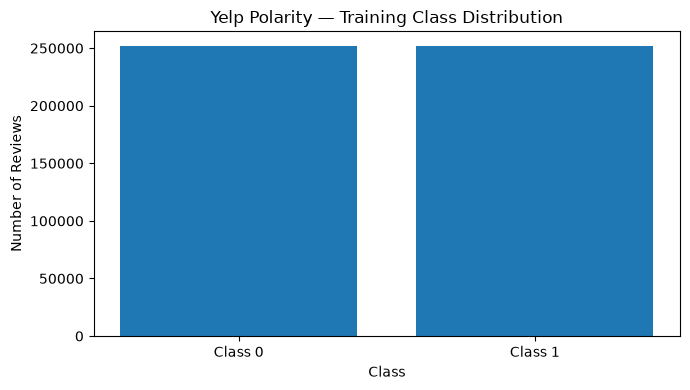

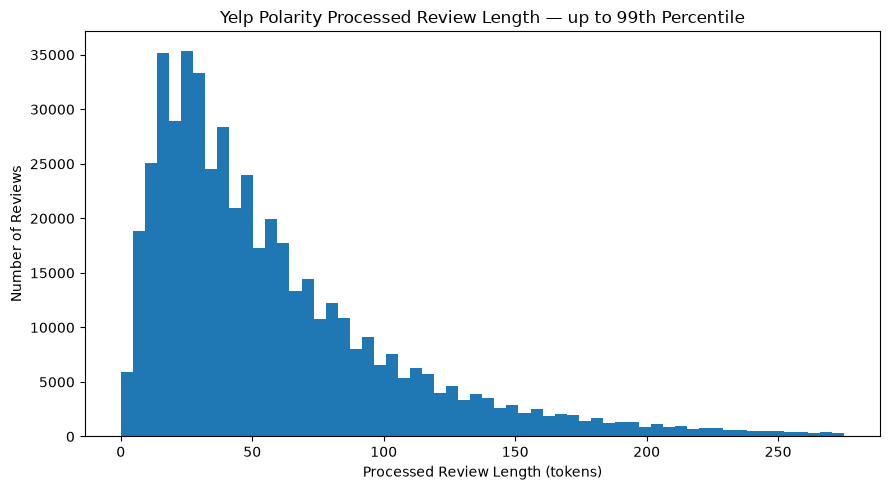

Plots saved.


In [14]:
# CELL 7 — Required plots

plt.figure(figsize=(7, 4))
plt.bar(["Class 0", "Class 1"], class_df["count"])
plt.xlabel("Class")
plt.ylabel("Number of Reviews")
plt.title("Yelp Polarity — Training Class Distribution")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "class_distribution.png",
    dpi=150
)
plt.show()


p99 = np.percentile(processed_lengths, 99)

plt.figure(figsize=(9, 5))
plt.hist(
    processed_lengths[processed_lengths <= p99],
    bins=60
)
plt.xlabel("Processed Review Length (tokens)")
plt.ylabel("Number of Reviews")
plt.title(
    "Yelp Polarity Processed Review Length — up to 99th Percentile"
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "processed_review_length_distribution.png",
    dpi=150
)
plt.show()

print("Plots saved.")

In [15]:
# CELL 8 — Final preprocessing settings

MAX_LEN = 256
MIN_FREQ = 5

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

PAD_IDX = 0
UNK_IDX = 1

coverage = (processed_lengths <= MAX_LEN).mean() * 100

print("MAX_LEN:", MAX_LEN)
print("MIN_FREQ:", MIN_FREQ)
print(f"Reviews fully covered: {coverage:.2f}%")
print(f"Reviews truncated: {100 - coverage:.2f}%")

MAX_LEN: 256
MIN_FREQ: 5
Reviews fully covered: 98.71%
Reviews truncated: 1.29%


In [16]:
# CELL 9 — Count vocabulary from training data only

token_counts = Counter()

for text in tqdm(
    data["train"]["text"],
    desc="Counting training tokens"
):
    token_counts.update(preprocess_text(text))

print("Unique training tokens:", f"{len(token_counts):,}")

Counting training tokens: 100%|██████████| 504000/504000 [01:06<00:00, 7544.70it/s]

Unique training tokens: 202,592


In [17]:
# CELL 10 — Deterministic vocabulary

eligible_tokens = [
    (token, count)
    for token, count in token_counts.items()
    if count >= MIN_FREQ
]

eligible_tokens.sort(
    key=lambda x: (-x[1], x[0])
)

word_to_idx = {
    PAD_TOKEN: PAD_IDX,
    UNK_TOKEN: UNK_IDX
}

for token, _ in eligible_tokens:
    word_to_idx[token] = len(word_to_idx)

idx_to_word = {
    idx: token
    for token, idx in word_to_idx.items()
}

VOCAB_SIZE = len(word_to_idx)

print("Vocabulary size:", f"{VOCAB_SIZE:,}")

print("\nFirst 20:")
for i in range(20):
    print(i, idx_to_word[i])

Vocabulary size: 60,713

First 20:
0 <PAD>
1 <UNK>
2 not
3 food
4 place
5 good
6 like
7 just
8 did
9 service
10 time
11 great
12 no
13 it's
14 really
15 got
16 never
17 ordered
18 nice
19 order


In [18]:
# CELL 11 — Save preprocessing artifacts

with open(
    DATA_PROCESSED_DIR / "word_to_idx.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        word_to_idx,
        f,
        ensure_ascii=False
    )


preprocessing_config = {
    "sid4": SID4,
    "seed": SEED,
    "max_len": MAX_LEN,
    "min_freq": MIN_FREQ,
    "vocab_size": VOCAB_SIZE,
    "pad_idx": PAD_IDX,
    "unk_idx": UNK_IDX,
    "train_size": len(data["train"]),
    "validation_size": len(data["validation"]),
    "test_size": len(data["test"])
}

with open(
    DATA_PROCESSED_DIR / "preprocessing_config.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        preprocessing_config,
        f,
        indent=2
    )

print("Vocabulary and preprocessing config saved.")

Vocabulary and preprocessing config saved.


In [20]:
# CELL 12 — Compact storage dtypes

print("Vocabulary size:", VOCAB_SIZE)
print("Maximum uint16 value:", np.iinfo(np.uint16).max)

assert VOCAB_SIZE <= np.iinfo(np.uint16).max

TOKEN_DTYPE = np.uint16
LABEL_DTYPE = np.uint8
LENGTH_DTYPE = np.uint16

print("\nuint16 token storage is SAFE.")

Vocabulary size: 60713
Maximum uint16 value: 65535

uint16 token storage is SAFE.


In [22]:
# CELL 13 — Memory-efficient split encoder

from numpy.lib.format import open_memmap


def encode_split(split, split_name):
    n = len(split)

    ids_path = DATA_PROCESSED_DIR / f"{split_name}_input_ids.npy"
    labels_path = DATA_PROCESSED_DIR / f"{split_name}_labels.npy"
    lengths_path = DATA_PROCESSED_DIR / f"{split_name}_lengths.npy"

    input_ids = open_memmap(
        ids_path,
        mode="w+",
        dtype=TOKEN_DTYPE,
        shape=(n, MAX_LEN)
    )

    labels = open_memmap(
        labels_path,
        mode="w+",
        dtype=LABEL_DTYPE,
        shape=(n,)
    )

    lengths = open_memmap(
        lengths_path,
        mode="w+",
        dtype=LENGTH_DTYPE,
        shape=(n,)
    )

    start = time.perf_counter()

    for i, row in enumerate(
        tqdm(split, total=n, desc=f"Encoding {split_name}")
    ):
        tokens = preprocess_text(row["text"])

        token_ids = [
            word_to_idx.get(token, UNK_IDX)
            for token in tokens[:MAX_LEN]
        ]

        seq_len = len(token_ids)

        # Pad the entire row
        input_ids[i, :] = PAD_IDX

        if seq_len > 0:
            input_ids[i, :seq_len] = token_ids

        labels[i] = row["label"]
        lengths[i] = seq_len

    input_ids.flush()
    labels.flush()
    lengths.flush()

    elapsed = time.perf_counter() - start

    print(f"\n{split_name} complete")
    print(f"Examples: {n:,}")
    print(f"Time: {elapsed:.2f} sec")
    print(f"Examples/sec: {n / elapsed:,.1f}")

    return {
        "split": split_name,
        "examples": n,
        "seconds": elapsed,
        "examples_per_sec": n / elapsed
    }

In [23]:
# CELL 14 — Encode training split

train_encoding_stats = encode_split(
    data["train"],
    "train"
)

print("\nTrain files:")

for path in sorted(DATA_PROCESSED_DIR.glob("train_*.npy")):
    print(
        f"{path.name:30s}",
        f"{path.stat().st_size / 1024**2:8.2f} MB"
    )

Encoding train: 100%|██████████| 504000/504000 [01:18<00:00, 6431.48it/s]


train complete
Examples: 504,000
Time: 78.43 sec
Examples/sec: 6,426.5

Train files:
train_input_ids.npy              246.09 MB
train_labels.npy                   0.48 MB
train_lengths.npy                  0.96 MB


In [24]:
# CELL 15 — Encode validation and test

validation_encoding_stats = encode_split(
    data["validation"],
    "validation"
)

test_encoding_stats = encode_split(
    data["test"],
    "test"
)

print("\nAll processed files:")

for path in sorted(DATA_PROCESSED_DIR.glob("*.npy")):
    print(
        f"{path.name:35s}",
        f"{path.stat().st_size / 1024**2:8.2f} MB"
    )

Encoding validation: 100%|██████████| 56000/56000 [00:08<00:00, 6743.24it/s]



validation complete
Examples: 56,000
Time: 8.32 sec
Examples/sec: 6,731.2


Encoding test: 100%|██████████| 38000/38000 [00:04<00:00, 8075.14it/s]


test complete
Examples: 38,000
Time: 4.71 sec
Examples/sec: 8,060.6

All processed files:
test_input_ids.npy                     18.55 MB
test_labels.npy                         0.04 MB
test_lengths.npy                        0.07 MB
train_input_ids.npy                   246.09 MB
train_labels.npy                        0.48 MB
train_lengths.npy                       0.96 MB
validation_input_ids.npy               27.34 MB
validation_labels.npy                   0.05 MB
validation_lengths.npy                  0.11 MB


In [25]:
# CELL 16 — Verify encoded arrays

train_ids = np.load(
    DATA_PROCESSED_DIR / "train_input_ids.npy",
    mmap_mode="r"
)

train_labels = np.load(
    DATA_PROCESSED_DIR / "train_labels.npy",
    mmap_mode="r"
)

train_lengths = np.load(
    DATA_PROCESSED_DIR / "train_lengths.npy",
    mmap_mode="r"
)

val_ids = np.load(
    DATA_PROCESSED_DIR / "validation_input_ids.npy",
    mmap_mode="r"
)

val_labels = np.load(
    DATA_PROCESSED_DIR / "validation_labels.npy",
    mmap_mode="r"
)

test_ids = np.load(
    DATA_PROCESSED_DIR / "test_input_ids.npy",
    mmap_mode="r"
)

test_labels = np.load(
    DATA_PROCESSED_DIR / "test_labels.npy",
    mmap_mode="r"
)

print("Train IDs:", train_ids.shape, train_ids.dtype)
print("Train labels:", train_labels.shape, train_labels.dtype)
print("Train lengths:", train_lengths.shape, train_lengths.dtype)

print("Validation IDs:", val_ids.shape, val_ids.dtype)
print("Validation labels:", val_labels.shape)

print("Test IDs:", test_ids.shape, test_ids.dtype)
print("Test labels:", test_labels.shape)

assert train_ids.shape == (504000, 256)
assert val_ids.shape == (56000, 256)
assert test_ids.shape == (38000, 256)

assert train_ids.max() < VOCAB_SIZE
assert train_labels.min() >= 0
assert train_labels.max() <= 1

print("\nEncoded dataset verification PASSED.")

Train IDs: (504000, 256) uint16
Train labels: (504000,) uint8
Train lengths: (504000,) uint16
Validation IDs: (56000, 256) uint16
Validation labels: (56000,)
Test IDs: (38000, 256) uint16
Test labels: (38000,)

Encoded dataset verification PASSED.


In [26]:
# CELL 17 — Decode sanity check

idx = 0

length = int(train_lengths[idx])

decoded_tokens = [
    idx_to_word[int(token_id)]
    for token_id in train_ids[idx, :length]
]

print("Decoded processed review:")
print(" ".join(decoded_tokens))

print("\nLabel:", int(train_labels[idx]))

Decoded processed review:
food great opened changed chefs quality food declined rubbery chicken tough steak cold atmosphere

Label: 0


In [27]:
# CELL 18 — Memory-mapped PyTorch Dataset

from torch.utils.data import Dataset, DataLoader


class YelpEncodedDataset(Dataset):
    def __init__(self, ids_path, labels_path, lengths_path):
        self.input_ids = np.load(ids_path, mmap_mode="r")
        self.labels = np.load(labels_path, mmap_mode="r")
        self.lengths = np.load(lengths_path, mmap_mode="r")

        assert len(self.input_ids) == len(self.labels)
        assert len(self.input_ids) == len(self.lengths)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Copy one row so PyTorch receives writable memory.
        input_ids = self.input_ids[idx].copy()

        return {
            "input_ids": torch.from_numpy(input_ids),
            "label": int(self.labels[idx]),
            "length": int(self.lengths[idx])
        }


print("YelpEncodedDataset ready.")

YelpEncodedDataset ready.


In [28]:
# CELL 19 — Instantiate datasets

train_dataset = YelpEncodedDataset(
    DATA_PROCESSED_DIR / "train_input_ids.npy",
    DATA_PROCESSED_DIR / "train_labels.npy",
    DATA_PROCESSED_DIR / "train_lengths.npy"
)

val_dataset = YelpEncodedDataset(
    DATA_PROCESSED_DIR / "validation_input_ids.npy",
    DATA_PROCESSED_DIR / "validation_labels.npy",
    DATA_PROCESSED_DIR / "validation_lengths.npy"
)

test_dataset = YelpEncodedDataset(
    DATA_PROCESSED_DIR / "test_input_ids.npy",
    DATA_PROCESSED_DIR / "test_labels.npy",
    DATA_PROCESSED_DIR / "test_lengths.npy"
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 504000
Validation: 56000
Test: 38000


In [29]:
# CELL 20 — DataLoader sanity test

CHECK_BATCH_SIZE = 64

loader_check = DataLoader(
    train_dataset,
    batch_size=CHECK_BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

batch = next(iter(loader_check))

print("Input IDs shape:", batch["input_ids"].shape)
print("Input dtype:", batch["input_ids"].dtype)

print("Labels shape:", batch["label"].shape)
print("Labels dtype:", batch["label"].dtype)

print("Lengths shape:", batch["length"].shape)

print("\nLabel counts:")
print(torch.bincount(batch["label"].long()))

Input IDs shape: torch.Size([64, 256])
Input dtype: torch.uint16
Labels shape: torch.Size([64])
Labels dtype: torch.int64
Lengths shape: torch.Size([64])

Label counts:
tensor([34, 30])


In [30]:
# CELL 21 — GPU readiness

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

free_mem, total_mem = torch.cuda.mem_get_info()

print("GPU:", torch.cuda.get_device_name(0))
print(f"Free VRAM:  {free_mem / 1024**3:.2f} GB")
print(f"Total VRAM: {total_mem / 1024**3:.2f} GB")

GPU: NVIDIA GeForce RTX 4090
Free VRAM:  22.50 GB
Total VRAM: 23.99 GB


## Model Lineup

### Baseline — C: Single-Layer GRU
Learned embedding → single unidirectional GRU → final hidden state → binary classifier.

### Experimental 1 — E: Bidirectional GRU
Learned embedding → single bidirectional GRU → concatenate final forward/backward hidden states → binary classifier.

### Experimental 2 — I: Stacked Bidirectional GRU
Learned embedding → two-layer bidirectional GRU → sequence pooling → MLP classifier.

All embedding layers are initialized randomly and trained from scratch.
No pretrained embeddings or pretrained language models are used.

In [31]:
# CELL 23 — Training environment

import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

PROJECT_ROOT = MEMBER_DIR.parent.parent

RAW_LOG_DIR = PROJECT_ROOT / "reproducibility" / "raw_logs"
MANIFEST_DIR = PROJECT_ROOT / "reproducibility" / "manifests"

RAW_LOG_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))
print("Raw logs:", RAW_LOG_DIR)
print("Checkpoints:", CHECKPOINT_DIR)

Device: cuda
GPU: NVIDIA GeForce RTX 4090
Raw logs: C:\Users\naveen\DATA266_Lab1\reproducibility\raw_logs
Checkpoints: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\checkpoints


In [37]:
# CELL 24 — DataLoader factory

def make_loaders(batch_size):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader

In [38]:
# CELL 25 — Baseline C: Single-Layer GRU

class GRUBaseline(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        pad_idx,
        dropout
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=pad_idx
        )

        self.embedding_dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )

        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, input_ids, lengths):
        x = self.embedding(input_ids)
        x = self.embedding_dropout(x)

        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, hidden = self.gru(packed)

        final_hidden = hidden[-1]

        logits = self.classifier(final_hidden).squeeze(1)

        return logits

In [39]:
# CELL 26 — Experimental E: Bidirectional GRU

class BiGRUClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        pad_idx,
        dropout
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=pad_idx
        )

        self.embedding_dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.classifier = nn.Linear(
            hidden_dim * 2,
            1
        )

    def forward(self, input_ids, lengths):
        x = self.embedding(input_ids)
        x = self.embedding_dropout(x)

        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, hidden = self.gru(packed)

        # hidden[-2] = forward final state
        # hidden[-1] = backward final state
        representation = torch.cat(
            [hidden[-2], hidden[-1]],
            dim=1
        )

        logits = self.classifier(
            representation
        ).squeeze(1)

        return logits

In [40]:
# CELL 27 — Experimental I: 2-Layer BiGRU + Pooling + MLP

class StackedBiGRUClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        pad_idx,
        dropout,
        pooling="mean"
    ):
        super().__init__()

        self.pooling = pooling

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=pad_idx
        )

        self.embedding_dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        if pooling == "meanmax":
            pooled_dim = hidden_dim * 4
        else:
            pooled_dim = hidden_dim * 2

        self.mlp = nn.Sequential(
            nn.Linear(pooled_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, input_ids, lengths):
        x = self.embedding(input_ids)
        x = self.embedding_dropout(x)

        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, _ = self.gru(packed)

        output, _ = pad_packed_sequence(
            packed_output,
            batch_first=True,
            total_length=input_ids.size(1)
        )

        max_len = output.size(1)

        mask = (
            torch.arange(max_len, device=output.device)
            .unsqueeze(0)
            < lengths.unsqueeze(1)
        )

        mask_float = mask.unsqueeze(-1).float()

        if self.pooling == "mean":
            summed = (output * mask_float).sum(dim=1)

            denom = lengths.clamp(min=1).unsqueeze(1).float()

            pooled = summed / denom

        elif self.pooling == "max":
            masked_output = output.masked_fill(
                ~mask.unsqueeze(-1),
                float("-inf")
            )

            pooled = masked_output.max(dim=1).values

        elif self.pooling == "meanmax":
            summed = (output * mask_float).sum(dim=1)

            denom = lengths.clamp(min=1).unsqueeze(1).float()

            mean_pool = summed / denom

            masked_output = output.masked_fill(
                ~mask.unsqueeze(-1),
                float("-inf")
            )

            max_pool = masked_output.max(dim=1).values

            pooled = torch.cat(
                [mean_pool, max_pool],
                dim=1
            )

        else:
            raise ValueError(
                f"Unknown pooling method: {self.pooling}"
            )

        logits = self.mlp(pooled).squeeze(1)

        return logits

In [41]:
# CELL 28 — Parameter count utility

def count_parameters(model):
    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    return total, trainable

In [42]:
# CELL 29 — Check encoded sequence lengths

for name, ds in [
    ("train", train_dataset),
    ("validation", val_dataset),
    ("test", test_dataset)
]:
    lengths = ds.lengths

    print(
        f"{name:12s} | "
        f"min={lengths.min()} | "
        f"max={lengths.max()} | "
        f"zero-length={(lengths == 0).sum()}"
    )

train        | min=0 | max=256 | zero-length=51
validation   | min=0 | max=256 | zero-length=3
test         | min=0 | max=256 | zero-length=1


In [43]:
# CELL 30 — Naveen Task 2 model configurations

MODEL_CONFIGS = {
    "baseline_gru": {
        "model_name": "Baseline C - Single-Layer GRU",
        "embedding_dim": 64,
        "hidden_dim": 64,
        "dropout": 0.2,
        "batch_size": 256,
        "learning_rate": 1e-3,
        "epochs": 3
    },

    "experimental_bigru": {
        "model_name": "Experimental E - Bidirectional GRU",
        "embedding_dim": 128,
        "hidden_dim": 128,
        "dropout": 0.3,
        "batch_size": 256,
        "learning_rate": 5e-4,
        "epochs": 5
    },

    "experimental_stacked_bigru": {
        "model_name": "Experimental I - 2-Layer BiGRU + MeanMax Pooling",
        "embedding_dim": 192,
        "hidden_dim": 192,
        "dropout": 0.4,
        "batch_size": 512,
        "learning_rate": 3e-4,
        "epochs": 8,
        "pooling": "meanmax"
    }
}

display(pd.DataFrame(MODEL_CONFIGS).T)

,model_name,embedding_dim,hidden_dim,dropout,batch_size,learning_rate,epochs,pooling
baseline_gru,Baseline C - Single-Layer GRU,64,64,0.2,256,0.001,3,NaN
experimental_bigru,Experimental E - Bidirectional GRU,128,128,0.3,256,0.0005,5,NaN
experimental_stacked_bigru,Experimental I - 2-Layer BiGRU + MeanMax Pooling,192,192,0.4,512,0.0003,8,meanmax


In [44]:
config_path = DATA_PROCESSED_DIR / "model_configs.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(MODEL_CONFIGS, f, indent=2)

print("Saved:", config_path)

Saved: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\data_processed\model_configs.json


In [45]:
# CELL 31 — Final model implementations

import torch.nn as nn
from torch.nn.utils.rnn import (
    pack_padded_sequence,
    pad_packed_sequence
)


class GRUBaseline(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        pad_idx,
        dropout
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=pad_idx
        )

        self.embedding_dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )

        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, input_ids, lengths):
        x = self.embedding(input_ids)
        x = self.embedding_dropout(x)

        safe_lengths = lengths.clamp(min=1)

        packed = pack_padded_sequence(
            x,
            safe_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, hidden = self.gru(packed)

        logits = self.classifier(
            hidden[-1]
        ).squeeze(1)

        return logits


class BiGRUClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        pad_idx,
        dropout
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=pad_idx
        )

        self.embedding_dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.classifier = nn.Linear(
            hidden_dim * 2,
            1
        )

    def forward(self, input_ids, lengths):
        x = self.embedding(input_ids)
        x = self.embedding_dropout(x)

        safe_lengths = lengths.clamp(min=1)

        packed = pack_padded_sequence(
            x,
            safe_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, hidden = self.gru(packed)

        representation = torch.cat(
            [hidden[-2], hidden[-1]],
            dim=1
        )

        logits = self.classifier(
            representation
        ).squeeze(1)

        return logits


class StackedBiGRUClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        pad_idx,
        dropout,
        pooling="meanmax"
    ):
        super().__init__()

        self.pooling = pooling

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=pad_idx
        )

        self.embedding_dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        if pooling == "meanmax":
            pooled_dim = hidden_dim * 4
        else:
            pooled_dim = hidden_dim * 2

        self.mlp = nn.Sequential(
            nn.Linear(pooled_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, input_ids, lengths):
        x = self.embedding(input_ids)
        x = self.embedding_dropout(x)

        safe_lengths = lengths.clamp(min=1)

        packed = pack_padded_sequence(
            x,
            safe_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, _ = self.gru(packed)

        output, _ = pad_packed_sequence(
            packed_output,
            batch_first=True,
            total_length=input_ids.size(1)
        )

        lengths_device = safe_lengths.to(output.device)

        positions = torch.arange(
            output.size(1),
            device=output.device
        ).unsqueeze(0)

        mask = positions < lengths_device.unsqueeze(1)

        mask_float = mask.unsqueeze(-1).float()

        mean_pool = (
            (output * mask_float).sum(dim=1)
            / lengths_device.unsqueeze(1).float()
        )

        masked_output = output.masked_fill(
            ~mask.unsqueeze(-1),
            float("-inf")
        )

        max_pool = masked_output.max(dim=1).values

        if self.pooling == "mean":
            pooled = mean_pool

        elif self.pooling == "max":
            pooled = max_pool

        elif self.pooling == "meanmax":
            pooled = torch.cat(
                [mean_pool, max_pool],
                dim=1
            )

        else:
            raise ValueError(
                f"Unknown pooling: {self.pooling}"
            )

        return self.mlp(pooled).squeeze(1)

In [46]:
# CELL 32 — Instantiate selected models

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

c = MODEL_CONFIGS["baseline_gru"]

baseline_model = GRUBaseline(
    vocab_size=VOCAB_SIZE,
    embedding_dim=c["embedding_dim"],
    hidden_dim=c["hidden_dim"],
    pad_idx=PAD_IDX,
    dropout=c["dropout"]
)


c = MODEL_CONFIGS["experimental_bigru"]

bigru_model = BiGRUClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=c["embedding_dim"],
    hidden_dim=c["hidden_dim"],
    pad_idx=PAD_IDX,
    dropout=c["dropout"]
)


c = MODEL_CONFIGS["experimental_stacked_bigru"]

stacked_bigru_model = StackedBiGRUClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=c["embedding_dim"],
    hidden_dim=c["hidden_dim"],
    pad_idx=PAD_IDX,
    dropout=c["dropout"],
    pooling=c["pooling"]
)

print("All three models instantiated.")

All three models instantiated.


In [47]:
# CELL 33 — Parameter counts

def count_parameters(model):
    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    return total, trainable


models = {
    "Baseline GRU": baseline_model,
    "BiGRU": bigru_model,
    "Stacked BiGRU": stacked_bigru_model
}

parameter_rows = []

for name, model in models.items():
    total, trainable = count_parameters(model)

    parameter_rows.append({
        "model": name,
        "total_parameters": total,
        "trainable_parameters": trainable
    })

parameter_df = pd.DataFrame(parameter_rows)

display(parameter_df)

,model,total_parameters,trainable_parameters
0,Baseline GRU,3910657,3910657
1,BiGRU,7969665,7969665
2,Stacked BiGRU,12915265,12915265


In [48]:
# CELL 34 — Forward-pass sanity tests

def test_model_forward(model, batch_size=8):
    loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    batch = next(iter(loader))

    input_ids = batch["input_ids"].to(
        DEVICE,
        dtype=torch.long
    )

    lengths = batch["length"].long()

    model = model.to(DEVICE)
    model.eval()

    with torch.no_grad():
        logits = model(
            input_ids,
            lengths
        )

    print(
        model.__class__.__name__,
        "->",
        logits.shape
    )

    assert logits.shape == (batch_size,)
    assert torch.isfinite(logits).all()

    model.cpu()
    torch.cuda.empty_cache()


test_model_forward(baseline_model)
test_model_forward(bigru_model)
test_model_forward(stacked_bigru_model)

print("\nAll forward-pass tests PASSED.")

GRUBaseline -> torch.Size([8])
BiGRUClassifier -> torch.Size([8])
StackedBiGRUClassifier -> torch.Size([8])

All forward-pass tests PASSED.


In [49]:
# CELL 35 — DataLoader factory

def make_loaders(batch_size):

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader


baseline_loaders = make_loaders(256)
bigru_loaders = make_loaders(256)
stacked_loaders = make_loaders(512)

print(
    "Baseline batches:",
    len(baseline_loaders[0])
)

print(
    "BiGRU batches:",
    len(bigru_loaders[0])
)

print(
    "Stacked BiGRU batches:",
    len(stacked_loaders[0])
)

Baseline batches: 1969
BiGRU batches: 1969
Stacked BiGRU batches: 985


In [50]:
# CELL 36 — Short training benchmark

def benchmark_model(
    model,
    train_loader,
    learning_rate,
    steps=20
):
    model = model.to(DEVICE)
    model.train()

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate
    )

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    loader_iter = iter(train_loader)

    # Warmup
    for _ in range(3):
        batch = next(loader_iter)

        input_ids = batch["input_ids"].to(
            DEVICE,
            dtype=torch.long,
            non_blocking=True
        )

        labels = batch["label"].to(
            DEVICE,
            dtype=torch.float32,
            non_blocking=True
        )

        lengths = batch["length"].long()

        optimizer.zero_grad(set_to_none=True)

        logits = model(input_ids, lengths)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

    torch.cuda.synchronize()

    start = time.perf_counter()

    examples = 0

    for _ in range(steps):
        try:
            batch = next(loader_iter)
        except StopIteration:
            loader_iter = iter(train_loader)
            batch = next(loader_iter)

        input_ids = batch["input_ids"].to(
            DEVICE,
            dtype=torch.long,
            non_blocking=True
        )

        labels = batch["label"].to(
            DEVICE,
            dtype=torch.float32,
            non_blocking=True
        )

        lengths = batch["length"].long()

        optimizer.zero_grad(set_to_none=True)

        logits = model(input_ids, lengths)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        examples += input_ids.size(0)

    torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    peak_gb = (
        torch.cuda.max_memory_allocated()
        / 1024**3
    )

    rate = examples / elapsed

    print("Model:", model.__class__.__name__)
    print(f"Loss: {loss.item():.4f}")
    print(f"Benchmark time: {elapsed:.2f} sec")
    print(f"Examples/sec: {rate:,.1f}")
    print(f"Peak GPU memory: {peak_gb:.2f} GB")

    model.cpu()
    torch.cuda.empty_cache()

    return {
        "examples_per_sec": rate,
        "peak_memory_gb": peak_gb
    }

In [51]:
baseline_benchmark = benchmark_model(
    baseline_model,
    baseline_loaders[0],
    learning_rate=1e-3
)

Model: GRUBaseline
Loss: 0.6696
Benchmark time: 0.67 sec
Examples/sec: 7,687.1
Peak GPU memory: 0.14 GB


In [52]:
bigru_benchmark = benchmark_model(
    bigru_model,
    bigru_loaders[0],
    learning_rate=5e-4
)

Model: BiGRUClassifier
Loss: 0.6244
Benchmark time: 1.14 sec
Examples/sec: 4,475.6
Peak GPU memory: 0.36 GB


In [53]:
stacked_benchmark = benchmark_model(
    stacked_bigru_model,
    stacked_loaders[0],
    learning_rate=3e-4
)

Model: StackedBiGRUClassifier
Loss: 0.5958
Benchmark time: 4.13 sec
Examples/sec: 2,480.9
Peak GPU memory: 1.36 GB


In [54]:
# CELL 37 — Patch reviews that became empty after preprocessing

def patch_empty_sequences(split_name):
    ids_path = DATA_PROCESSED_DIR / f"{split_name}_input_ids.npy"
    lengths_path = DATA_PROCESSED_DIR / f"{split_name}_lengths.npy"

    ids = np.load(ids_path, mmap_mode="r+")
    lengths = np.load(lengths_path, mmap_mode="r+")

    zero_indices = np.flatnonzero(lengths == 0)

    print(f"{split_name}: {len(zero_indices)} zero-length sequences")

    if len(zero_indices) > 0:
        ids[zero_indices, 0] = UNK_IDX
        lengths[zero_indices] = 1

        ids.flush()
        lengths.flush()

    print(
        f"{split_name}: remaining zero-length = "
        f"{int((lengths == 0).sum())}"
    )


patch_empty_sequences("train")
patch_empty_sequences("validation")
patch_empty_sequences("test")

train: 51 zero-length sequences
train: remaining zero-length = 0
validation: 3 zero-length sequences
validation: remaining zero-length = 0
test: 1 zero-length sequences
test: remaining zero-length = 0


In [55]:
# Document empty-review handling

config_path = DATA_PROCESSED_DIR / "preprocessing_config.json"

with open(config_path, "r", encoding="utf-8") as f:
    saved_config = json.load(f)

saved_config["empty_after_preprocessing"] = (
    "Replace with one <UNK> token and set sequence length to 1"
)

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(saved_config, f, indent=2)

print("Updated:", config_path)

Updated: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\data_processed\preprocessing_config.json


In [56]:
train_dataset = YelpEncodedDataset(
    DATA_PROCESSED_DIR / "train_input_ids.npy",
    DATA_PROCESSED_DIR / "train_labels.npy",
    DATA_PROCESSED_DIR / "train_lengths.npy"
)

val_dataset = YelpEncodedDataset(
    DATA_PROCESSED_DIR / "validation_input_ids.npy",
    DATA_PROCESSED_DIR / "validation_labels.npy",
    DATA_PROCESSED_DIR / "validation_lengths.npy"
)

test_dataset = YelpEncodedDataset(
    DATA_PROCESSED_DIR / "test_input_ids.npy",
    DATA_PROCESSED_DIR / "test_labels.npy",
    DATA_PROCESSED_DIR / "test_lengths.npy"
)

print("Train zero lengths:", int((train_dataset.lengths == 0).sum()))
print("Val zero lengths:", int((val_dataset.lengths == 0).sum()))
print("Test zero lengths:", int((test_dataset.lengths == 0).sum()))

Train zero lengths: 0
Val zero lengths: 0
Test zero lengths: 0


In [57]:
# CELL 38 — Fresh model factory

def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def build_fresh_model(model_key):
    reset_seed(SEED)

    cfg = MODEL_CONFIGS[model_key]

    if model_key == "baseline_gru":
        model = GRUBaseline(
            vocab_size=VOCAB_SIZE,
            embedding_dim=cfg["embedding_dim"],
            hidden_dim=cfg["hidden_dim"],
            pad_idx=PAD_IDX,
            dropout=cfg["dropout"]
        )

    elif model_key == "experimental_bigru":
        model = BiGRUClassifier(
            vocab_size=VOCAB_SIZE,
            embedding_dim=cfg["embedding_dim"],
            hidden_dim=cfg["hidden_dim"],
            pad_idx=PAD_IDX,
            dropout=cfg["dropout"]
        )

    elif model_key == "experimental_stacked_bigru":
        model = StackedBiGRUClassifier(
            vocab_size=VOCAB_SIZE,
            embedding_dim=cfg["embedding_dim"],
            hidden_dim=cfg["hidden_dim"],
            pad_idx=PAD_IDX,
            dropout=cfg["dropout"],
            pooling=cfg["pooling"]
        )

    else:
        raise ValueError(f"Unknown model key: {model_key}")

    return model

In [58]:
for model_key in MODEL_CONFIGS:
    fresh_model = build_fresh_model(model_key)

    print(
        model_key,
        f"{count_parameters(fresh_model)[0]:,}"
    )

baseline_gru 3,910,657
experimental_bigru 7,969,665
experimental_stacked_bigru 12,915,265


In [59]:
# CELL 39 — Hardware information

import platform
import subprocess


try:
    CPU_NAME = subprocess.check_output(
        [
            "powershell",
            "-NoProfile",
            "-Command",
            "(Get-CimInstance Win32_Processor).Name"
        ],
        text=True
    ).strip()
except Exception:
    CPU_NAME = platform.processor()


GPU_NAME = (
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "CPU"
)

print("CPU:", CPU_NAME)
print("GPU:", GPU_NAME)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)

CPU: AMD Ryzen 9 7950X 16-Core Processor
GPU: NVIDIA GeForce RTX 4090
PyTorch: 2.14.0+cu130
CUDA: 13.0


In [60]:
# CELL 40 — Validation function

from sklearn.metrics import accuracy_score, f1_score


@torch.no_grad()
def evaluate_during_training(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_examples = 0

    all_labels = []
    all_probs = []

    for batch in loader:
        input_ids = batch["input_ids"].to(
            DEVICE,
            dtype=torch.long,
            non_blocking=True
        )

        labels = batch["label"].to(
            DEVICE,
            dtype=torch.float32,
            non_blocking=True
        )

        lengths = batch["length"].long()

        logits = model(input_ids, lengths)

        loss = criterion(logits, labels)

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_examples += batch_size

        probs = torch.sigmoid(logits)

        all_probs.extend(
            probs.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy().astype(int)
        )

    avg_loss = total_loss / total_examples

    all_probs = np.asarray(all_probs)
    all_labels = np.asarray(all_labels)

    predictions = (all_probs >= 0.5).astype(int)

    accuracy = accuracy_score(
        all_labels,
        predictions
    )

    macro_f1 = f1_score(
        all_labels,
        predictions,
        average="macro"
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

In [61]:
# CELL 41 — Official training function

def train_official_model(model_key):

    cfg = MODEL_CONFIGS[model_key]

    # IMPORTANT: clean initialization after benchmark
    model = build_fresh_model(model_key).to(DEVICE)

    train_loader, val_loader, _ = make_loaders(
        cfg["batch_size"]
    )

    criterion = nn.BCEWithLogitsLoss()

    # Same optimizer family for all three models;
    # learning rate is model-specific according to your config.
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg["learning_rate"]
    )

    checkpoint_best = (
        CHECKPOINT_DIR / f"{model_key}_best.pt"
    )

    checkpoint_last = (
        CHECKPOINT_DIR / f"{model_key}_last.pt"
    )

    history_path = (
        MEMBER_DIR / f"{model_key}_training_history.csv"
    )

    raw_log_path = (
        RAW_LOG_DIR / f"task2_naveen_{model_key}_training_raw.txt"
    )

    history = []

    best_val_loss = float("inf")
    best_epoch = None

    total_train_examples = 0
    cumulative_train_seconds = 0.0

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    run_start = time.perf_counter()

    # File is created once and written during training.
    with open(
        raw_log_path,
        "w",
        encoding="utf-8",
        buffering=1
    ) as log:

        def write_log(message):
            print(message)
            log.write(message + "\n")

        write_log("=" * 90)
        write_log("DATA266 LAB 1 - TASK 2 OFFICIAL TRAINING RUN")
        write_log("=" * 90)

        write_log(f"Model key: {model_key}")
        write_log(f"Model: {cfg['model_name']}")
        write_log(f"Seed: {SEED}")
        write_log(f"CPU: {CPU_NAME}")
        write_log(f"GPU: {GPU_NAME}")
        write_log(f"PyTorch: {torch.__version__}")
        write_log(f"CUDA runtime: {torch.version.cuda}")
        write_log(f"Vocabulary size: {VOCAB_SIZE}")
        write_log(f"MAX_LEN: {MAX_LEN}")

        write_log(
            f"Embedding dim: {cfg['embedding_dim']}"
        )
        write_log(
            f"Hidden dim: {cfg['hidden_dim']}"
        )
        write_log(
            f"Dropout: {cfg['dropout']}"
        )
        write_log(
            f"Batch size: {cfg['batch_size']}"
        )
        write_log(
            f"Learning rate: {cfg['learning_rate']}"
        )
        write_log(
            f"Epochs: {cfg['epochs']}"
        )

        if "pooling" in cfg:
            write_log(
                f"Pooling: {cfg['pooling']}"
            )

        params, _ = count_parameters(model)

        write_log(f"Parameters: {params:,}")
        write_log("-" * 90)

        for epoch in range(1, cfg["epochs"] + 1):

            model.train()

            epoch_loss_sum = 0.0
            epoch_examples = 0

            torch.cuda.synchronize()
            train_start = time.perf_counter()

            for batch in train_loader:

                input_ids = batch["input_ids"].to(
                    DEVICE,
                    dtype=torch.long,
                    non_blocking=True
                )

                labels = batch["label"].to(
                    DEVICE,
                    dtype=torch.float32,
                    non_blocking=True
                )

                lengths = batch["length"].long()

                optimizer.zero_grad(
                    set_to_none=True
                )

                logits = model(
                    input_ids,
                    lengths
                )

                loss = criterion(
                    logits,
                    labels
                )

                loss.backward()

                optimizer.step()

                batch_size = labels.size(0)

                epoch_loss_sum += (
                    loss.item() * batch_size
                )

                epoch_examples += batch_size

            torch.cuda.synchronize()

            train_seconds = (
                time.perf_counter() - train_start
            )

            cumulative_train_seconds += train_seconds
            total_train_examples += epoch_examples

            train_loss = (
                epoch_loss_sum / epoch_examples
            )

            train_examples_per_sec = (
                epoch_examples / train_seconds
            )

            val_metrics = evaluate_during_training(
                model,
                val_loader,
                criterion
            )

            peak_memory_gb = (
                torch.cuda.max_memory_allocated()
                / 1024**3
            )

            row = {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "train_seconds": train_seconds,
                "train_examples_per_sec":
                    train_examples_per_sec,
                "peak_memory_gb":
                    peak_memory_gb
            }

            history.append(row)

            write_log(
                f"Epoch {epoch:02d}/{cfg['epochs']} | "
                f"Train Loss {train_loss:.4f} | "
                f"Val Loss {val_metrics['loss']:.4f} | "
                f"Val Acc {val_metrics['accuracy']*100:.2f}% | "
                f"Val Macro-F1 {val_metrics['macro_f1']:.4f} | "
                f"{train_examples_per_sec:,.1f} ex/s | "
                f"{train_seconds:.1f}s"
            )

            # Best checkpoint chosen by validation loss
            if val_metrics["loss"] < best_val_loss:

                best_val_loss = val_metrics["loss"]
                best_epoch = epoch

                torch.save({
                    "model_key": model_key,
                    "model_state_dict":
                        model.state_dict(),
                    "epoch": epoch,
                    "val_loss":
                        val_metrics["loss"],
                    "val_accuracy":
                        val_metrics["accuracy"],
                    "val_macro_f1":
                        val_metrics["macro_f1"],
                    "config": cfg,
                    "seed": SEED,
                    "vocab_size": VOCAB_SIZE,
                    "max_len": MAX_LEN
                }, checkpoint_best)

                write_log(
                    f"  -> Saved BEST checkpoint "
                    f"(epoch {epoch})"
                )

        total_run_seconds = (
            time.perf_counter() - run_start
        )

        overall_examples_per_sec = (
            total_train_examples /
            cumulative_train_seconds
        )

        final_peak_memory_gb = (
            torch.cuda.max_memory_allocated()
            / 1024**3
        )

        torch.save({
            "model_key": model_key,
            "model_state_dict":
                model.state_dict(),
            "epoch": cfg["epochs"],
            "config": cfg,
            "seed": SEED,
            "vocab_size": VOCAB_SIZE,
            "max_len": MAX_LEN
        }, checkpoint_last)

        write_log("-" * 90)
        write_log(
            f"Best epoch: {best_epoch}"
        )
        write_log(
            f"Best validation loss: "
            f"{best_val_loss:.6f}"
        )
        write_log(
            f"Total run time: "
            f"{total_run_seconds/60:.2f} min"
        )
        write_log(
            f"Training examples/sec: "
            f"{overall_examples_per_sec:,.1f}"
        )
        write_log(
            f"Peak GPU memory: "
            f"{final_peak_memory_gb:.2f} GB"
        )

        write_log(
            f"Best checkpoint: "
            f"{checkpoint_best.name}"
        )

        write_log(
            f"Last checkpoint: "
            f"{checkpoint_last.name}"
        )

        write_log("=" * 90)

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        history_path,
        index=False
    )

    summary = {
        "model_key": model_key,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "training_examples_per_sec":
            overall_examples_per_sec,
        "peak_memory_gb":
            final_peak_memory_gb,
        "total_run_seconds":
            total_run_seconds,
        "best_checkpoint":
            str(checkpoint_best),
        "last_checkpoint":
            str(checkpoint_last),
        "raw_log":
            str(raw_log_path)
    }

    model.cpu()
    torch.cuda.empty_cache()

    return history_df, summary

In [62]:
# CELL 42 — OFFICIAL RUN 1: Baseline C

baseline_history, baseline_summary = train_official_model(
    "baseline_gru"
)

DATA266 LAB 1 - TASK 2 OFFICIAL TRAINING RUN
Model key: baseline_gru
Model: Baseline C - Single-Layer GRU
Seed: 171
CPU: AMD Ryzen 9 7950X 16-Core Processor
GPU: NVIDIA GeForce RTX 4090
PyTorch: 2.14.0+cu130
CUDA runtime: 13.0
Vocabulary size: 60713
MAX_LEN: 256
Embedding dim: 64
Hidden dim: 64
Dropout: 0.2
Batch size: 256
Learning rate: 0.001
Epochs: 3
Parameters: 3,910,657
------------------------------------------------------------------------------------------
Epoch 01/3 | Train Loss 0.2724 | Val Loss 0.2052 | Val Acc 92.44% | Val Macro-F1 0.9244 | 9,485.5 ex/s | 53.1s
  -> Saved BEST checkpoint (epoch 1)
Epoch 02/3 | Train Loss 0.1806 | Val Loss 0.1718 | Val Acc 93.23% | Val Macro-F1 0.9322 | 9,626.1 ex/s | 52.4s
  -> Saved BEST checkpoint (epoch 2)
Epoch 03/3 | Train Loss 0.1557 | Val Loss 0.1574 | Val Acc 93.87% | Val Macro-F1 0.9387 | 8,834.4 ex/s | 57.0s
  -> Saved BEST checkpoint (epoch 3)
---------------------------------------------------------------------------------------

In [65]:
display(baseline_history)

print("\nBASELINE SUMMARY")
for key, value in baseline_summary.items():
    print(f"{key}: {value}")

,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,train_seconds,train_examples_per_sec,peak_memory_gb
0,1,0.272418,0.205207,0.924375,0.924375,53.133906,9485.468729,0.139700
1,2,0.180605,0.171774,0.932268,0.932244,52.357677,9626.095501,0.139700
2,3,0.155736,0.157442,0.938679,0.938678,57.049959,8834.362239,0.140038



BASELINE SUMMARY
model_key: baseline_gru
best_epoch: 3
best_val_loss: 0.15744248972620284
training_examples_per_sec: 9302.237372102485
peak_memory_gb: 0.14003849029541016
total_run_seconds: 169.81626870000036
best_checkpoint: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\checkpoints\baseline_gru_best.pt
last_checkpoint: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\checkpoints\baseline_gru_last.pt
raw_log: C:\Users\naveen\DATA266_Lab1\reproducibility\raw_logs\task2_naveen_baseline_gru_training_raw.txt


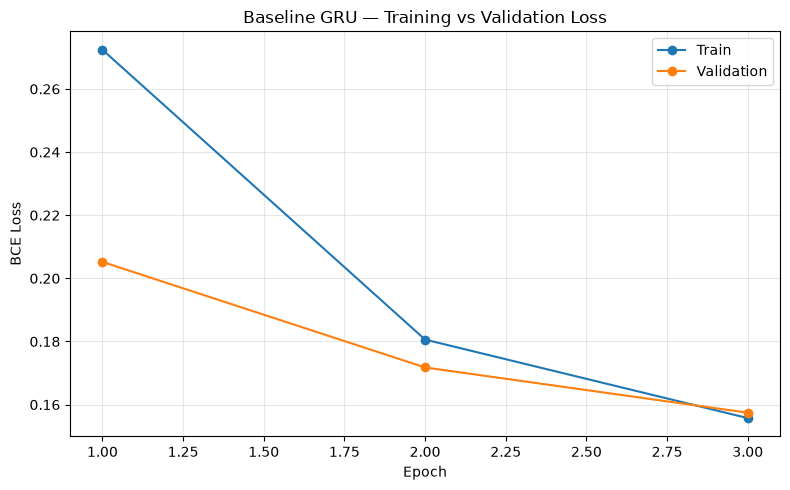

Saved: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\outputs\baseline_gru_loss_curve.png


In [66]:
# CELL 43 — Baseline loss curve

plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history["epoch"],
    baseline_history["train_loss"],
    marker="o",
    label="Train"
)

plt.plot(
    baseline_history["epoch"],
    baseline_history["val_loss"],
    marker="o",
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Baseline GRU — Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

baseline_curve_path = (
    OUTPUT_DIR / "baseline_gru_loss_curve.png"
)

plt.savefig(
    baseline_curve_path,
    dpi=150
)

plt.show()

print("Saved:", baseline_curve_path)

In [67]:
# CELL 44 — OFFICIAL RUN 2: Experimental E - Bidirectional GRU

bigru_history, bigru_summary = train_official_model(
    "experimental_bigru"
)

DATA266 LAB 1 - TASK 2 OFFICIAL TRAINING RUN
Model key: experimental_bigru
Model: Experimental E - Bidirectional GRU
Seed: 171
CPU: AMD Ryzen 9 7950X 16-Core Processor
GPU: NVIDIA GeForce RTX 4090
PyTorch: 2.14.0+cu130
CUDA runtime: 13.0
Vocabulary size: 60713
MAX_LEN: 256
Embedding dim: 128
Hidden dim: 128
Dropout: 0.3
Batch size: 256
Learning rate: 0.0005
Epochs: 5
Parameters: 7,969,665
------------------------------------------------------------------------------------------
Epoch 01/5 | Train Loss 0.2647 | Val Loss 0.2533 | Val Acc 91.74% | Val Macro-F1 0.9174 | 5,223.2 ex/s | 96.5s
  -> Saved BEST checkpoint (epoch 1)
Epoch 02/5 | Train Loss 0.1869 | Val Loss 0.1790 | Val Acc 93.40% | Val Macro-F1 0.9340 | 5,255.8 ex/s | 95.9s
  -> Saved BEST checkpoint (epoch 2)
Epoch 03/5 | Train Loss 0.1645 | Val Loss 0.1897 | Val Acc 93.60% | Val Macro-F1 0.9360 | 5,167.8 ex/s | 97.5s
Epoch 04/5 | Train Loss 0.1515 | Val Loss 0.1694 | Val Acc 93.97% | Val Macro-F1 0.9397 | 5,118.5 ex/s | 98.5s

In [68]:
# CELL 45 — BiGRU training summary

display(bigru_history)

print("\nBIGRU SUMMARY")

for key, value in bigru_summary.items():
    print(f"{key}: {value}")

,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,train_seconds,train_examples_per_sec,peak_memory_gb
0,1,0.264714,0.253336,0.917375,0.917373,96.491767,5223.243576,0.382106
1,2,0.186939,0.178979,0.934018,0.934008,95.894798,5255.759562,0.385871
2,3,0.164528,0.189657,0.936000,0.936000,97.526155,5167.844478,0.388520
3,4,0.151521,0.169399,0.939750,0.939746,98.465450,5118.546642,0.388520
4,5,0.140181,0.167524,0.941357,0.941354,96.691777,5212.439088,0.388520



BIGRU SUMMARY
model_key: experimental_bigru
best_epoch: 5
best_val_loss: 0.16752377096244267
training_examples_per_sec: 5195.127047437018
peak_memory_gb: 0.3885197639465332
total_run_seconds: 505.3928384000001
best_checkpoint: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\checkpoints\experimental_bigru_best.pt
last_checkpoint: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\checkpoints\experimental_bigru_last.pt
raw_log: C:\Users\naveen\DATA266_Lab1\reproducibility\raw_logs\task2_naveen_experimental_bigru_training_raw.txt


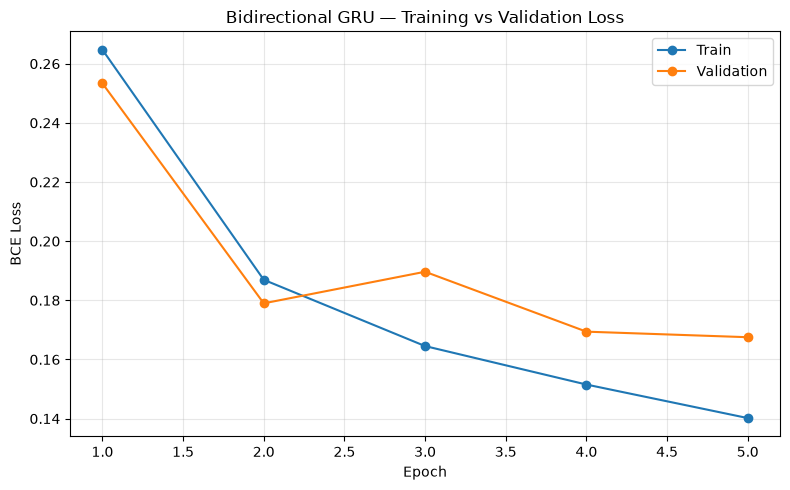

Saved: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\outputs\experimental_bigru_loss_curve.png


In [69]:
# CELL 46 — BiGRU loss curve

plt.figure(figsize=(8, 5))

plt.plot(
    bigru_history["epoch"],
    bigru_history["train_loss"],
    marker="o",
    label="Train"
)

plt.plot(
    bigru_history["epoch"],
    bigru_history["val_loss"],
    marker="o",
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Bidirectional GRU — Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

bigru_curve_path = (
    OUTPUT_DIR / "experimental_bigru_loss_curve.png"
)

plt.savefig(
    bigru_curve_path,
    dpi=150
)

plt.show()

print("Saved:", bigru_curve_path)

In [70]:
# CELL 47 — Verify Experimental E artifacts

bigru_expected_files = [
    CHECKPOINT_DIR / "experimental_bigru_best.pt",
    CHECKPOINT_DIR / "experimental_bigru_last.pt",
    MEMBER_DIR / "experimental_bigru_training_history.csv",
    RAW_LOG_DIR / "task2_naveen_experimental_bigru_training_raw.txt",
    OUTPUT_DIR / "experimental_bigru_loss_curve.png",
]

for path in bigru_expected_files:
    print(
        "OK" if path.exists() else "MISSING",
        "-",
        path.name
    )

OK - experimental_bigru_best.pt
OK - experimental_bigru_last.pt
OK - experimental_bigru_training_history.csv
OK - task2_naveen_experimental_bigru_training_raw.txt
OK - experimental_bigru_loss_curve.png


In [79]:
# CELL 48 — OFFICIAL RUN 3
# Experimental I: 2-Layer BiGRU + MeanMax Pooling
#
# OFFICIAL TRAINING RUN ALREADY COMPLETED.
# Do not rerun unless intentionally retraining from scratch.

RUN_STACKED_TRAINING = False

if RUN_STACKED_TRAINING:
    stacked_history, stacked_summary = train_official_model(
        "experimental_stacked_bigru"
    )
else:
    print("Official Experimental I training already completed.")
    print("Loading saved history/checkpoint instead.")

Official Experimental I training already completed.
Loading saved history/checkpoint instead.


In [80]:
# CELL 49 — Load completed Experimental I run

stacked_history = pd.read_csv(
    MEMBER_DIR / "experimental_stacked_bigru_training_history.csv"
)

stacked_ckpt = torch.load(
    CHECKPOINT_DIR / "experimental_stacked_bigru_best.pt",
    map_location="cpu"
)

stacked_summary = {
    "model_key": "experimental_stacked_bigru",
    "best_epoch": int(stacked_ckpt["epoch"]),
    "best_val_loss": float(stacked_ckpt["val_loss"]),
    "best_val_accuracy": float(stacked_ckpt["val_accuracy"]),
    "best_val_macro_f1": float(stacked_ckpt["val_macro_f1"]),
    "parameters": 12_915_265
}

display(stacked_history)

print("\nSTACKED BIGRU — SAVED OFFICIAL RUN")

for key, value in stacked_summary.items():
    print(f"{key}: {value}")

print("\nHistory rows:", len(stacked_history))

,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,train_seconds,train_examples_per_sec,peak_memory_gb
0,1,0.289206,0.220223,0.917321,0.917246,195.801741,2574.032277,1.400043
1,2,0.207400,0.191316,0.930571,0.930571,195.991774,2571.536499,1.429930
2,3,0.186990,0.191195,0.931911,0.931884,196.974101,2558.712019,1.429930
3,4,0.173975,0.173831,0.938089,0.938087,196.459931,2565.408619,1.429930
4,5,0.163203,0.172071,0.940304,0.940301,195.938017,2572.242019,1.429930
5,6,0.155422,0.178052,0.938411,0.938392,196.427048,2565.838079,1.429930
6,7,0.149513,0.161809,0.943161,0.943160,196.128273,2569.746790,1.429930
7,8,0.143889,0.164736,0.943821,0.943819,197.523461,2551.595636,1.429930



STACKED BIGRU — SAVED OFFICIAL RUN
model_key: experimental_stacked_bigru
best_epoch: 7
best_val_loss: 0.1618092085974557
best_val_accuracy: 0.9431607142857142
best_val_macro_f1: 0.9431595171374194
parameters: 12915265

History rows: 8


In [77]:
ckpt = torch.load(
    CHECKPOINT_DIR / "experimental_stacked_bigru_best.pt",
    map_location="cpu"
)

print("Saved epoch:", ckpt["epoch"])
print("Validation loss:", ckpt["val_loss"])
print("Validation accuracy:", ckpt["val_accuracy"])
print("Validation macro-F1:", ckpt["val_macro_f1"])

Saved epoch: 7
Validation loss: 0.1618092085974557
Validation accuracy: 0.9431607142857142
Validation macro-F1: 0.9431595171374194


In [78]:
recovered_history = pd.read_csv(
    MEMBER_DIR / "experimental_stacked_bigru_training_history.csv"
)

display(recovered_history)
print("Rows:", len(recovered_history))

,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,train_seconds,train_examples_per_sec,peak_memory_gb
0,1,0.289206,0.220223,0.917321,0.917246,195.801741,2574.032277,1.400043
1,2,0.207400,0.191316,0.930571,0.930571,195.991774,2571.536499,1.429930
2,3,0.186990,0.191195,0.931911,0.931884,196.974101,2558.712019,1.429930
3,4,0.173975,0.173831,0.938089,0.938087,196.459931,2565.408619,1.429930
4,5,0.163203,0.172071,0.940304,0.940301,195.938017,2572.242019,1.429930
5,6,0.155422,0.178052,0.938411,0.938392,196.427048,2565.838079,1.429930
6,7,0.149513,0.161809,0.943161,0.943160,196.128273,2569.746790,1.429930
7,8,0.143889,0.164736,0.943821,0.943819,197.523461,2551.595636,1.429930


Rows: 8


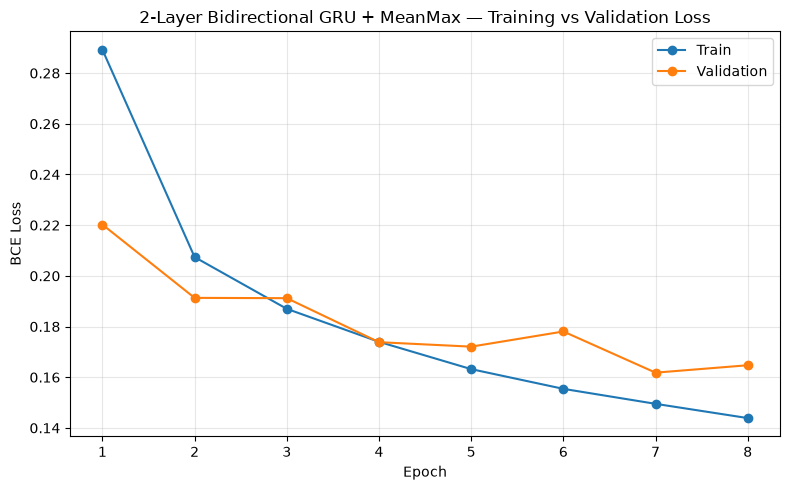

Saved: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\outputs\experimental_stacked_bigru_loss_curve.png


In [82]:
# CELL 50 — Stacked BiGRU loss curve

plt.figure(figsize=(8, 5))

plt.plot(
    stacked_history["epoch"],
    stacked_history["train_loss"],
    marker="o",
    label="Train"
)

plt.plot(
    stacked_history["epoch"],
    stacked_history["val_loss"],
    marker="o",
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title(
    "2-Layer Bidirectional GRU + MeanMax — "
    "Training vs Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

stacked_curve_path = (
    OUTPUT_DIR /
    "experimental_stacked_bigru_loss_curve.png"
)

plt.savefig(
    stacked_curve_path,
    dpi=150
)

plt.show()

print("Saved:", stacked_curve_path)

In [83]:
# CELL 51 — Verify Experimental I artifacts

stacked_expected_files = [
    CHECKPOINT_DIR /
        "experimental_stacked_bigru_best.pt",

    CHECKPOINT_DIR /
        "experimental_stacked_bigru_last.pt",

    MEMBER_DIR /
        "experimental_stacked_bigru_training_history.csv",

    RAW_LOG_DIR /
        "task2_naveen_experimental_stacked_bigru_training_raw.txt",

    OUTPUT_DIR /
        "experimental_stacked_bigru_loss_curve.png",
]

for path in stacked_expected_files:
    print(
        "OK" if path.exists() else "MISSING",
        "-",
        path.name
    )

OK - experimental_stacked_bigru_best.pt
OK - experimental_stacked_bigru_last.pt
OK - experimental_stacked_bigru_training_history.csv
OK - task2_naveen_experimental_stacked_bigru_training_raw.txt
OK - experimental_stacked_bigru_loss_curve.png


In [75]:
# CELL 52 — Training-run comparison

training_comparison = pd.DataFrame([
    {
        "model": "Baseline GRU",
        "best_epoch": baseline_summary["best_epoch"],
        "best_val_loss": baseline_summary["best_val_loss"],
        "examples_per_sec":
            baseline_summary["training_examples_per_sec"],
        "peak_memory_gb":
            baseline_summary["peak_memory_gb"],
        "total_minutes":
            baseline_summary["total_run_seconds"] / 60,
        "parameters": 3910657
    },
    {
        "model": "Bidirectional GRU",
        "best_epoch": bigru_summary["best_epoch"],
        "best_val_loss": bigru_summary["best_val_loss"],
        "examples_per_sec":
            bigru_summary["training_examples_per_sec"],
        "peak_memory_gb":
            bigru_summary["peak_memory_gb"],
        "total_minutes":
            bigru_summary["total_run_seconds"] / 60,
        "parameters": 7969665
    },
    {
        "model": "2-Layer BiGRU + MeanMax",
        "best_epoch": stacked_summary["best_epoch"],
        "best_val_loss": stacked_summary["best_val_loss"],
        "examples_per_sec":
            stacked_summary["training_examples_per_sec"],
        "peak_memory_gb":
            stacked_summary["peak_memory_gb"],
        "total_minutes":
            stacked_summary["total_run_seconds"] / 60,
        "parameters": 12915265
    }
])

display(training_comparison.round(4))

,model,best_epoch,best_val_loss,examples_per_sec,peak_memory_gb,total_minutes,parameters
0,Baseline GRU,3,0.1574,9302.2374,0.1400,2.8303,3910657
1,Bidirectional GRU,5,0.1675,5195.1270,0.3885,8.4232,7969665
2,2-Layer BiGRU + MeanMax,7,0.1618,2566.1190,1.4299,26.7961,12915265


In [84]:
# CELL 52 — Evaluation imports

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    brier_score_loss
)

import numpy as np
import pandas as pd
import torch

print("Evaluation imports ready.")

Evaluation imports ready.


In [90]:
# CELL 53 — Load saved best model

def load_best_model(model_key):
    model = build_fresh_model(model_key)

    checkpoint_path = (
        CHECKPOINT_DIR / f"{model_key}_best.pt"
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu"
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model = model.to(DEVICE)
    model.eval()

    print(
        model_key,
        "| saved epoch:",
        checkpoint["epoch"],
        "| val loss:",
        round(float(checkpoint["val_loss"]), 6)
    )

    return model, checkpoint

In [91]:
for model_key in [
    "baseline_gru",
    "experimental_bigru",
    "experimental_stacked_bigru"
]:
    model, checkpoint = load_best_model(model_key)
    model.cpu()
    del model
    torch.cuda.empty_cache()

baseline_gru | saved epoch: 3 | val loss: 0.157442
experimental_bigru | saved epoch: 5 | val loss: 0.167524
experimental_stacked_bigru | saved epoch: 7 | val loss: 0.161809


In [94]:
# Verify all three best checkpoints

for model_key in [
    "baseline_gru",
    "experimental_bigru",
    "experimental_stacked_bigru"
]:
    model, checkpoint = load_best_model(model_key)

    model.cpu()
    del model

    torch.cuda.empty_cache()

baseline_gru | saved epoch: 3 | val loss: 0.157442
experimental_bigru | saved epoch: 5 | val loss: 0.167524
experimental_stacked_bigru | saved epoch: 7 | val loss: 0.161809


In [95]:
# CELL 54 — Generate test predictions

@torch.no_grad()
def predict_model(model, loader):

    model.eval()

    all_labels = []
    all_probs = []
    all_lengths = []

    start = time.perf_counter()

    for batch in loader:

        input_ids = batch["input_ids"].to(
            DEVICE,
            dtype=torch.long,
            non_blocking=True
        )

        lengths = batch["length"].long()

        logits = model(
            input_ids,
            lengths
        )

        probs = torch.sigmoid(logits)

        all_probs.append(
            probs.cpu().numpy()
        )

        all_labels.append(
            batch["label"].numpy()
        )

        all_lengths.append(
            batch["length"].numpy()
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    labels = np.concatenate(all_labels)
    probs = np.concatenate(all_probs)
    lengths = np.concatenate(all_lengths)

    preds = (
        probs >= 0.5
    ).astype(np.int64)

    return {
        "labels": labels,
        "probs": probs,
        "preds": preds,
        "lengths": lengths,
        "inference_seconds": elapsed,
        "examples_per_sec":
            len(labels) / elapsed
    }

In [96]:
# CELL 55 — Common test loader

EVAL_BATCH_SIZE = 512

evaluation_test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Test batches:", len(evaluation_test_loader))

Test batches: 75


In [97]:
# CELL 56 — Generate predictions for all models

prediction_results = {}

for model_key in [
    "baseline_gru",
    "experimental_bigru",
    "experimental_stacked_bigru"
]:

    print("\n" + "=" * 80)
    print("Evaluating:", model_key)

    model, checkpoint = load_best_model(
        model_key
    )

    result = predict_model(
        model,
        evaluation_test_loader
    )

    result["best_epoch"] = int(
        checkpoint["epoch"]
    )

    prediction_results[model_key] = result

    print(
        f"Test examples: {len(result['labels']):,}"
    )

    print(
        f"Inference time: "
        f"{result['inference_seconds']:.2f} sec"
    )

    print(
        f"Inference throughput: "
        f"{result['examples_per_sec']:,.1f} ex/s"
    )

    model.cpu()
    del model

    torch.cuda.empty_cache()


Evaluating: baseline_gru
baseline_gru | saved epoch: 3 | val loss: 0.157442
Test examples: 38,000
Inference time: 1.22 sec
Inference throughput: 31,167.9 ex/s

Evaluating: experimental_bigru
experimental_bigru | saved epoch: 5 | val loss: 0.167524
Test examples: 38,000
Inference time: 1.82 sec
Inference throughput: 20,896.1 ex/s

Evaluating: experimental_stacked_bigru
experimental_stacked_bigru | saved epoch: 7 | val loss: 0.161809
Test examples: 38,000
Inference time: 3.54 sec
Inference throughput: 10,725.9 ex/s


In [98]:
# CELL 57 — Save model predictions

test_texts = data["test"]["text"]

for model_key, result in prediction_results.items():

    pred_df = pd.DataFrame({
        "index": np.arange(
            len(result["labels"])
        ),
        "label": result["labels"],
        "prediction": result["preds"],
        "prob_positive": result["probs"],
        "processed_length": result["lengths"],
        "text": test_texts
    })

    output_path = (
        OUTPUT_DIR /
        f"{model_key}_test_predictions.csv"
    )

    pred_df.to_csv(
        output_path,
        index=False
    )

    print(
        model_key,
        "->",
        output_path
    )

baseline_gru -> C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\outputs\baseline_gru_test_predictions.csv
experimental_bigru -> C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\outputs\experimental_bigru_test_predictions.csv
experimental_stacked_bigru -> C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\outputs\experimental_stacked_bigru_test_predictions.csv


In [99]:
# CELL 58 — Expected Calibration Error

def expected_calibration_error(
    labels,
    probs,
    n_bins=15
):
    labels = np.asarray(labels)
    probs = np.asarray(probs)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    for i in range(n_bins):

        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == n_bins - 1:
            mask = (
                (probs >= lower) &
                (probs <= upper)
            )
        else:
            mask = (
                (probs >= lower) &
                (probs < upper)
            )

        if not np.any(mask):
            continue

        bin_probs = probs[mask]
        bin_labels = labels[mask]

        confidence = bin_probs.mean()

        # Fraction positive is the empirical
        # probability of class 1
        observed = bin_labels.mean()

        ece += (
            mask.mean()
            * abs(confidence - observed)
        )

    return float(ece)

In [100]:
# CELL 59 — Compute required core metrics

def calculate_core_metrics(
    labels,
    preds,
    probs
):

    metrics = {}

    metrics["accuracy"] = accuracy_score(
        labels,
        preds
    )

    for average in [
        "macro",
        "micro",
        "weighted"
    ]:

        precision, recall, f1, _ = (
            precision_recall_fscore_support(
                labels,
                preds,
                average=average,
                zero_division=0
            )
        )

        metrics[
            f"precision_{average}"
        ] = precision

        metrics[
            f"recall_{average}"
        ] = recall

        metrics[
            f"f1_{average}"
        ] = f1

    metrics["roc_auc"] = roc_auc_score(
        labels,
        probs
    )

    metrics["pr_auc"] = (
        average_precision_score(
            labels,
            probs
        )
    )

    metrics["mcc"] = matthews_corrcoef(
        labels,
        preds
    )

    metrics["brier_score"] = (
        brier_score_loss(
            labels,
            probs
        )
    )

    metrics["ece_15_bins"] = (
        expected_calibration_error(
            labels,
            probs,
            n_bins=15
        )
    )

    return metrics

In [101]:
# CELL 60 — Core test metrics

core_metric_rows = []

for model_key, result in prediction_results.items():

    metrics = calculate_core_metrics(
        result["labels"],
        result["preds"],
        result["probs"]
    )

    metrics["model_key"] = model_key

    metrics["best_epoch"] = (
        result["best_epoch"]
    )

    metrics[
        "test_inference_examples_per_sec"
    ] = result["examples_per_sec"]

    core_metric_rows.append(metrics)


core_metrics_df = pd.DataFrame(
    core_metric_rows
)

cols = [
    "model_key",
    "best_epoch",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_micro",
    "recall_micro",
    "f1_micro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
    "roc_auc",
    "pr_auc",
    "mcc",
    "brier_score",
    "ece_15_bins",
    "test_inference_examples_per_sec"
]

core_metrics_df = (
    core_metrics_df[cols]
)

display(
    core_metrics_df.round(5)
)

,model_key,best_epoch,accuracy,precision_macro,recall_macro,f1_macro,precision_micro,recall_micro,f1_micro,precision_weighted,recall_weighted,f1_weighted,roc_auc,pr_auc,mcc,brier_score,ece_15_bins,test_inference_examples_per_sec
0,baseline_gru,3,0.94276,0.94281,0.94276,0.94276,0.94276,0.94276,0.94276,0.94281,0.94276,0.94276,0.98660,0.98696,0.88557,0.04345,0.01146,31167.90231
1,experimental_bigru,5,0.94461,0.94468,0.94461,0.94460,0.94461,0.94461,0.94461,0.94468,0.94461,0.94460,0.98642,0.98614,0.88929,0.04274,0.01895,20896.12022
2,experimental_stacked_bigru,7,0.94613,0.94615,0.94613,0.94613,0.94613,0.94613,0.94613,0.94615,0.94613,0.94613,0.98814,0.98852,0.89229,0.04172,0.02112,10725.93464


In [102]:
core_metrics_df.to_csv(
    OUTPUT_DIR / "core_test_metrics.csv",
    index=False
)

print("Core metrics saved.")

Core metrics saved.


In [103]:
# CELL 61 — Confusion matrices

for model_key, result in prediction_results.items():

    cm = confusion_matrix(
        result["labels"],
        result["preds"]
    )

    print("\n", model_key)
    print(cm)

    cm_df = pd.DataFrame(
        cm,
        index=[
            "Actual 0",
            "Actual 1"
        ],
        columns=[
            "Predicted 0",
            "Predicted 1"
        ]
    )

    cm_df.to_csv(
        OUTPUT_DIR /
        f"{model_key}_confusion_matrix.csv"
    )

    plt.figure(figsize=(5, 4))

    plt.imshow(cm)

    plt.title(
        f"{MODEL_CONFIGS[model_key]['model_name']}\n"
        "Test Confusion Matrix"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks([0, 1])
    plt.yticks([0, 1])

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center"
            )

    plt.colorbar()
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR /
        f"{model_key}_confusion_matrix.png",
        dpi=150
    )

    plt.close()

print("\nConfusion matrices saved.")


 baseline_gru
[[17818  1182]
 [  993 18007]]

 experimental_bigru
[[17822  1178]
 [  927 18073]]

 experimental_stacked_bigru
[[18045   955]
 [ 1092 17908]]

Confusion matrices saved.


In [104]:
# CELL 62 — 95% Bootstrap CIs
# Accuracy, Macro-F1, MCC

def binary_metrics_fast(y_true, y_pred):
    codes = y_true.astype(np.int64) * 2 + y_pred.astype(np.int64)

    counts = np.bincount(codes, minlength=4)

    tn, fp, fn, tp = counts

    n = tn + fp + fn + tp

    accuracy = (tp + tn) / n

    # F1 for positive class
    denom_pos = 2 * tp + fp + fn
    f1_pos = (
        2 * tp / denom_pos
        if denom_pos > 0
        else 0.0
    )

    # F1 for negative class
    denom_neg = 2 * tn + fp + fn
    f1_neg = (
        2 * tn / denom_neg
        if denom_neg > 0
        else 0.0
    )

    macro_f1 = (f1_pos + f1_neg) / 2

    mcc_denom = np.sqrt(
        (tp + fp) *
        (tp + fn) *
        (tn + fp) *
        (tn + fn)
    )

    mcc = (
        ((tp * tn) - (fp * fn)) / mcc_denom
        if mcc_denom > 0
        else 0.0
    )

    return accuracy, macro_f1, mcc


def bootstrap_ci(
    labels,
    preds,
    n_bootstrap=1000,
    seed=SEED
):
    labels = np.asarray(labels)
    preds = np.asarray(preds)

    n = len(labels)

    rng = np.random.default_rng(seed)

    boot_accuracy = np.empty(n_bootstrap)
    boot_macro_f1 = np.empty(n_bootstrap)
    boot_mcc = np.empty(n_bootstrap)

    for i in tqdm(
        range(n_bootstrap),
        desc="Bootstrap"
    ):
        idx = rng.integers(
            0,
            n,
            size=n
        )

        acc, macro_f1, mcc = binary_metrics_fast(
            labels[idx],
            preds[idx]
        )

        boot_accuracy[i] = acc
        boot_macro_f1[i] = macro_f1
        boot_mcc[i] = mcc

    return {
        "accuracy_ci_low":
            np.percentile(boot_accuracy, 2.5),

        "accuracy_ci_high":
            np.percentile(boot_accuracy, 97.5),

        "macro_f1_ci_low":
            np.percentile(boot_macro_f1, 2.5),

        "macro_f1_ci_high":
            np.percentile(boot_macro_f1, 97.5),

        "mcc_ci_low":
            np.percentile(boot_mcc, 2.5),

        "mcc_ci_high":
            np.percentile(boot_mcc, 97.5)
    }

In [105]:
bootstrap_rows = []

for model_key, result in prediction_results.items():

    print("\n", model_key)

    ci = bootstrap_ci(
        result["labels"],
        result["preds"],
        n_bootstrap=1000,
        seed=SEED
    )

    ci["model_key"] = model_key

    bootstrap_rows.append(ci)


bootstrap_df = pd.DataFrame(
    bootstrap_rows
)

bootstrap_df = bootstrap_df[
    [
        "model_key",
        "accuracy_ci_low",
        "accuracy_ci_high",
        "macro_f1_ci_low",
        "macro_f1_ci_high",
        "mcc_ci_low",
        "mcc_ci_high"
    ]
]

display(bootstrap_df.round(5))

bootstrap_df.to_csv(
    OUTPUT_DIR / "bootstrap_95ci.csv",
    index=False
)


 baseline_gru


Bootstrap: 100%|██████████| 1000/1000 [00:00<00:00, 3135.20it/s]



 experimental_bigru


Bootstrap: 100%|██████████| 1000/1000 [00:00<00:00, 3079.53it/s]



 experimental_stacked_bigru


Bootstrap: 100%|██████████| 1000/1000 [00:00<00:00, 3162.88it/s]


,model_key,accuracy_ci_low,accuracy_ci_high,macro_f1_ci_low,macro_f1_ci_high,mcc_ci_low,mcc_ci_high
0,baseline_gru,0.94029,0.94524,0.94029,0.94523,0.88061,0.89052
1,experimental_bigru,0.94242,0.94713,0.94242,0.94713,0.88494,0.89434
2,experimental_stacked_bigru,0.94397,0.94850,0.94396,0.94850,0.88796,0.89701


In [106]:
# CELL 63 — Exact paired McNemar tests

from scipy.stats import binomtest


def exact_mcnemar(
    labels,
    baseline_preds,
    comparison_preds
):
    labels = np.asarray(labels)

    baseline_correct = (
        baseline_preds == labels
    )

    comparison_correct = (
        comparison_preds == labels
    )

    # Baseline correct, comparison wrong
    b = np.sum(
        baseline_correct &
        ~comparison_correct
    )

    # Baseline wrong, comparison correct
    c = np.sum(
        ~baseline_correct &
        comparison_correct
    )

    discordant = b + c

    if discordant == 0:
        p_value = 1.0
    else:
        p_value = binomtest(
            min(b, c),
            n=discordant,
            p=0.5,
            alternative="two-sided"
        ).pvalue

    return {
        "baseline_correct_comparison_wrong":
            int(b),

        "baseline_wrong_comparison_correct":
            int(c),

        "discordant_pairs":
            int(discordant),

        "exact_p_value":
            float(p_value)
    }

In [107]:
labels = prediction_results[
    "baseline_gru"
]["labels"]

baseline_preds = prediction_results[
    "baseline_gru"
]["preds"]


mcnemar_rows = []

for comparison_key in [
    "experimental_bigru",
    "experimental_stacked_bigru"
]:

    result = exact_mcnemar(
        labels,
        baseline_preds,
        prediction_results[
            comparison_key
        ]["preds"]
    )

    result["comparison"] = (
        f"baseline_gru vs {comparison_key}"
    )

    mcnemar_rows.append(result)


mcnemar_df = pd.DataFrame(
    mcnemar_rows
)

display(mcnemar_df)

mcnemar_df.to_csv(
    OUTPUT_DIR / "mcnemar_tests.csv",
    index=False
)

,baseline_correct_comparison_wrong,baseline_wrong_comparison_correct,discordant_pairs,exact_p_value,comparison
0,564,634,1198,0.046159,baseline_gru vs experimental_bigru
1,553,681,1234,0.000297,baseline_gru vs experimental_stacked_bigru


In [108]:
# CELL 64 — Define evaluation slices

test_lengths_np = prediction_results[
    "baseline_gru"
]["lengths"]

test_texts_np = np.asarray(
    data["test"]["text"]
)


slice_masks = {
    "short_0_64": (
        test_lengths_np <= 64
    ),

    "medium_65_128": (
        (test_lengths_np > 64) &
        (test_lengths_np <= 128)
    ),

    "long_129_plus": (
        test_lengths_np > 128
    )
}


negation_pattern = re.compile(
    r"\b(no|not|never|cannot)\b|n't",
    flags=re.IGNORECASE
)

has_negation = np.asarray([
    bool(negation_pattern.search(text))
    for text in test_texts_np
])

slice_masks["has_negation"] = has_negation
slice_masks["no_negation"] = ~has_negation


print("Slice sizes:")

for slice_name, mask in slice_masks.items():
    print(
        f"{slice_name:20s}: "
        f"{mask.sum():,}"
    )

Slice sizes:
short_0_64          : 25,262
medium_65_128       : 9,048
long_129_plus       : 3,690
has_negation        : 27,938
no_negation         : 10,062


In [109]:
# CELL 65 — Robustness metrics by slice

slice_rows = []

for model_key, result in prediction_results.items():

    labels = result["labels"]
    preds = result["preds"]

    for slice_name, mask in slice_masks.items():

        y_slice = labels[mask]
        p_slice = preds[mask]

        macro_f1 = precision_recall_fscore_support(
            y_slice,
            p_slice,
            average="macro",
            zero_division=0
        )[2]

        error_rate = (
            p_slice != y_slice
        ).mean()

        slice_rows.append({
            "model_key": model_key,
            "slice": slice_name,
            "n_examples": int(mask.sum()),
            "macro_f1": macro_f1,
            "error_rate": error_rate
        })


slice_metrics_df = pd.DataFrame(
    slice_rows
)

display(
    slice_metrics_df.round(5)
)

slice_metrics_df.to_csv(
    OUTPUT_DIR / "slice_robustness_metrics.csv",
    index=False
)

,model_key,slice,n_examples,macro_f1,error_rate
0,baseline_gru,short_0_64,25262,0.94461,0.05502
1,baseline_gru,medium_65_128,9048,0.93748,0.06189
2,baseline_gru,long_129_plus,3690,0.93451,0.06098
3,baseline_gru,has_negation,27938,0.93853,0.05956
4,baseline_gru,no_negation,10062,0.93156,0.05079
5,experimental_bigru,short_0_64,25262,0.94668,0.05293
6,experimental_bigru,medium_65_128,9048,0.94029,0.05913
7,experimental_bigru,long_129_plus,3690,0.93155,0.06314
8,experimental_bigru,has_negation,27938,0.94148,0.05673
9,experimental_bigru,no_negation,10062,0.93017,0.05168


In [110]:
slice_f1_pivot = (
    slice_metrics_df
    .pivot(
        index="slice",
        columns="model_key",
        values="macro_f1"
    )
)

print("MACRO-F1 BY SLICE")
display(slice_f1_pivot.round(5))


slice_error_pivot = (
    slice_metrics_df
    .pivot(
        index="slice",
        columns="model_key",
        values="error_rate"
    )
)

print("\nERROR RATE BY SLICE")
display(slice_error_pivot.round(5))

MACRO-F1 BY SLICE


model_key,baseline_gru,experimental_bigru,experimental_stacked_bigru
slice,,,
has_negation,0.93853,0.94148,0.94318
long_129_plus,0.93451,0.93155,0.93858
medium_65_128,0.93748,0.94029,0.94239
no_negation,0.93156,0.93017,0.93188
short_0_64,0.94461,0.94668,0.94734



ERROR RATE BY SLICE


model_key,baseline_gru,experimental_bigru,experimental_stacked_bigru
slice,,,
has_negation,0.05956,0.05673,0.05487
long_129_plus,0.06098,0.06314,0.05664
medium_65_128,0.06189,0.05913,0.05692
no_negation,0.05079,0.05168,0.05108
short_0_64,0.05502,0.05293,0.05237


In [111]:
# CELL 66 — Merge core metrics + confidence intervals

metrics_with_ci = core_metrics_df.merge(
    bootstrap_df,
    on="model_key",
    how="left"
)

display(
    metrics_with_ci.round(5)
)

,model_key,best_epoch,accuracy,precision_macro,recall_macro,f1_macro,precision_micro,recall_micro,f1_micro,precision_weighted,...,mcc,brier_score,ece_15_bins,test_inference_examples_per_sec,accuracy_ci_low,accuracy_ci_high,macro_f1_ci_low,macro_f1_ci_high,mcc_ci_low,mcc_ci_high
0,baseline_gru,3,0.94276,0.94281,0.94276,0.94276,0.94276,0.94276,0.94276,0.94281,...,0.88557,0.04345,0.01146,31167.90231,0.94029,0.94524,0.94029,0.94523,0.88061,0.89052
1,experimental_bigru,5,0.94461,0.94468,0.94461,0.94460,0.94461,0.94461,0.94461,0.94468,...,0.88929,0.04274,0.01895,20896.12022,0.94242,0.94713,0.94242,0.94713,0.88494,0.89434
2,experimental_stacked_bigru,7,0.94613,0.94615,0.94613,0.94613,0.94613,0.94613,0.94613,0.94615,...,0.89229,0.04172,0.02112,10725.93464,0.94397,0.94850,0.94396,0.94850,0.88796,0.89701


In [112]:
metrics_with_ci.to_csv(
    OUTPUT_DIR / "metrics_with_confidence_intervals.csv",
    index=False
)

print("Saved statistical metrics.")

Saved statistical metrics.


In [113]:
# CELL 67 — Model selected for manual error review

ERROR_MODEL_KEY = "experimental_stacked_bigru"

error_result = prediction_results[ERROR_MODEL_KEY]

print("Manual error-review model:", ERROR_MODEL_KEY)
print("Total test errors:",
      int((error_result["preds"] != error_result["labels"]).sum()))

Manual error-review model: experimental_stacked_bigru
Total test errors: 2047


In [115]:
# CELL 68 — Build error dataframe

error_df = pd.DataFrame({
    "index": np.arange(len(error_result["labels"])),
    "label": error_result["labels"],
    "prediction": error_result["preds"],
    "prob_positive": error_result["probs"],
    "processed_length": error_result["lengths"],
    "text": data["test"]["text"]
})

error_df["is_error"] = (
    error_df["label"] != error_df["prediction"]
)

error_df["confidence"] = np.where(
    error_df["prediction"] == 1,
    error_df["prob_positive"],
    1.0 - error_df["prob_positive"]
)

error_df["distance_from_threshold"] = (
    np.abs(error_df["prob_positive"] - 0.5)
)

error_df["has_negation"] = error_df["text"].str.contains(
    r"\b(no|not|never|cannot)\b|n't",
    case=False,
    regex=True
)

error_df["is_long"] = (
    error_df["processed_length"] > 128
)

errors_only = error_df[
    error_df["is_error"]
].copy()

print("Errors:", len(errors_only))
display(errors_only.head())

Errors: 2047


C:\Users\naveen\AppData\Local\Temp\ipykernel_47728\2654734570.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  error_df["has_negation"] = error_df["text"].str.contains(


,index,label,prediction,prob_positive,processed_length,text,is_error,confidence,distance_from_threshold,has_negation,is_long
0,0,1,0,0.100019,55,"Contrary to other reviews, I have zero complai...",True,0.899981,0.399981,True,False
35,35,0,1,0.711530,72,"I don't know, maybe I'm not clear on the conce...",True,0.711530,0.211530,True,False
74,74,1,0,0.168068,24,"Something different here.\n\nFood, schmood, go...",True,0.831932,0.331932,True,False
91,91,1,0,0.114610,16,"The store is small, but it carries specialties...",True,0.885390,0.385390,False,False
99,99,0,1,0.658199,21,This place holds a nostalgic appeal for people...,True,0.658199,0.158199,False,False


In [116]:
# CELL 69 — Confident false positives

confident_fp = (
    errors_only[
        (errors_only["label"] == 0) &
        (errors_only["prediction"] == 1)
    ]
    .sort_values(
        "prob_positive",
        ascending=False
    )
    .head(5)
    .copy()
)

confident_fp["review_category"] = "confident_false_positive"

display(
    confident_fp[
        [
            "index",
            "label",
            "prediction",
            "prob_positive",
            "processed_length",
            "text"
        ]
    ]
)

,index,label,prediction,prob_positive,processed_length,text
29330,29330,0,1,0.999938,17,Wow love the place and everything is very clea...
408,408,0,1,0.999878,53,Though I'm a Copper enthusiast when it comes t...
501,501,0,1,0.999777,41,Laser quest is a fun experience for kids of al...
8426,8426,0,1,0.999665,213,Saturday / Sunday AYCE brunch\n\nIn true las v...
18794,18794,0,1,0.999598,26,You can do yourself a huge favor and have all ...


In [117]:
# CELL 70 — Confident false negatives

confident_fn = (
    errors_only[
        (errors_only["label"] == 1) &
        (errors_only["prediction"] == 0)
    ]
    .sort_values(
        "prob_positive",
        ascending=True
    )
    .head(5)
    .copy()
)

confident_fn["review_category"] = "confident_false_negative"

display(
    confident_fn[
        [
            "index",
            "label",
            "prediction",
            "prob_positive",
            "processed_length",
            "text"
        ]
    ]
)

,index,label,prediction,prob_positive,processed_length,text
30793,30793,1,0,0.000038,37,This place is so much better since they change...
22807,22807,1,0,0.000040,47,EDIT: They really did change the service up si...
20061,20061,1,0,0.000052,256,Ever wonder what to do if you have lots of ext...
9871,9871,1,0,0.000122,129,"After a major screw up by me, booking the room..."
26172,26172,1,0,0.000136,77,"I had to eat here at least once, and would eat..."


In [118]:
# CELL 71 — Near-threshold errors

already_selected = set(
    confident_fp["index"].tolist()
    +
    confident_fn["index"].tolist()
)

near_threshold_pool = errors_only[
    ~errors_only["index"].isin(already_selected)
].copy()

near_threshold = (
    near_threshold_pool
    .sort_values(
        "distance_from_threshold",
        ascending=True
    )
    .head(5)
    .copy()
)

near_threshold["review_category"] = "near_threshold_error"

display(
    near_threshold[
        [
            "index",
            "label",
            "prediction",
            "prob_positive",
            "distance_from_threshold",
            "processed_length",
            "text"
        ]
    ]
)

,index,label,prediction,prob_positive,distance_from_threshold,processed_length,text
20109,20109,0,1,0.500004,0.000004,22,"Food was good but, not great. Location is very..."
36081,36081,0,1,0.500132,0.000132,58,"Summary: great location, great micro brew, rea..."
3993,3993,1,0,0.499149,0.000851,10,"The place is open 24/7, is pretty quick with o..."
861,861,1,0,0.499005,0.000995,218,"Summer time is supposed to be \""""healthy time\..."
13662,13662,0,1,0.501028,0.001028,70,The Bistro Buffet at the Palms is not among my...


In [119]:
# CELL 72 — Slice-specific failures

already_selected.update(
    near_threshold["index"].tolist()
)

slice_pool = errors_only[
    ~errors_only["index"].isin(already_selected)
].copy()

slice_pool["slice_priority"] = (
    slice_pool["is_long"].astype(int)
    +
    slice_pool["has_negation"].astype(int)
)

slice_specific = (
    slice_pool[
        (slice_pool["is_long"]) |
        (slice_pool["has_negation"])
    ]
    .sort_values(
        [
            "slice_priority",
            "confidence"
        ],
        ascending=[
            False,
            False
        ]
    )
    .head(5)
    .copy()
)

slice_specific["review_category"] = "slice_specific_failure"

slice_specific["slice"] = np.select(
    [
        slice_specific["is_long"]
        & slice_specific["has_negation"],

        slice_specific["is_long"],

        slice_specific["has_negation"]
    ],
    [
        "long + negation",
        "long review",
        "negation"
    ],
    default="other"
)

display(
    slice_specific[
        [
            "index",
            "label",
            "prediction",
            "prob_positive",
            "processed_length",
            "slice",
            "text"
        ]
    ]
)

,index,label,prediction,prob_positive,processed_length,slice,text
9477,9477,1,0,0.000180,256,long + negation,"Before getting started, I'd like to point out ..."
30958,30958,1,0,0.000212,181,long + negation,"Look, we all know Cox sucks. In fact they are ..."
29494,29494,1,0,0.000411,141,long + negation,UPDATED. \n\nMy initial very frustrated and dr...
5752,5752,0,1,0.999198,207,long + negation,"NOTE: This was a 4-star review, but the food ..."
21813,21813,1,0,0.001149,227,long + negation,Our flight arrived to Vegas earlier than excep...


In [120]:
# CELL 73 — Combine required 20 errors

manual_error_review = pd.concat(
    [
        confident_fp,
        confident_fn,
        near_threshold,
        slice_specific
    ],
    ignore_index=True
)

print("Total cases:", len(manual_error_review))
print(
    "Unique cases:",
    manual_error_review["index"].nunique()
)

print("\nCategory counts:")
print(
    manual_error_review[
        "review_category"
    ].value_counts()
)

assert len(manual_error_review) == 20
assert manual_error_review["index"].nunique() == 20

print("\n20-error selection PASSED.")

Total cases: 20
Unique cases: 20

Category counts:
review_category
confident_false_positive    5
confident_false_negative    5
near_threshold_error        5
slice_specific_failure      5
Name: count, dtype: int64

20-error selection PASSED.


In [121]:
# CELL 74 — Manual error-analysis worksheet

review_columns = [
    "review_category",
    "index",
    "label",
    "prediction",
    "prob_positive",
    "processed_length",
    "text"
]

manual_review_sheet = (
    manual_error_review[
        review_columns
    ].copy()
)

manual_review_sheet["error_type"] = ""
manual_review_sheet["observation"] = ""
manual_review_sheet["testable_fix"] = ""

manual_review_path = (
    OUTPUT_DIR /
    "manual_20_error_review.csv"
)

manual_review_sheet.to_csv(
    manual_review_path,
    index=False
)

display(manual_review_sheet)

print("\nSaved:", manual_review_path)

,review_category,index,label,prediction,prob_positive,processed_length,text,error_type,observation,testable_fix
0,confident_false_positive,29330,0,1,0.999938,17,Wow love the place and everything is very clea...,,,
1,confident_false_positive,408,0,1,0.999878,53,Though I'm a Copper enthusiast when it comes t...,,,
2,confident_false_positive,501,0,1,0.999777,41,Laser quest is a fun experience for kids of al...,,,
3,confident_false_positive,8426,0,1,0.999665,213,Saturday / Sunday AYCE brunch\n\nIn true las v...,,,
4,confident_false_positive,18794,0,1,0.999598,26,You can do yourself a huge favor and have all ...,,,
5,confident_false_negative,30793,1,0,0.000038,37,This place is so much better since they change...,,,
6,confident_false_negative,22807,1,0,0.000040,47,EDIT: They really did change the service up si...,,,
7,confident_false_negative,20061,1,0,0.000052,256,Ever wonder what to do if you have lots of ext...,,,
8,confident_false_negative,9871,1,0,0.000122,129,"After a major screw up by me, booking the room...",,,
9,confident_false_negative,26172,1,0,0.000136,77,"I had to eat here at least once, and would eat...",,,



Saved: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\outputs\manual_20_error_review.csv


In [122]:
# CELL 76 — Recovery note

recovery_note = """# Task 2 Experimental I — Raw Log Recovery Note

The official Experimental I training run completed successfully for all 8 epochs.

Preserved evidence:
- Best checkpoint: experimental_stacked_bigru_best.pt
- Best epoch: 7
- Best validation loss: 0.161809
- Validation accuracy at best checkpoint: 0.943161
- Validation macro-F1 at best checkpoint: 0.943160
- Last checkpoint: experimental_stacked_bigru_last.pt
- Complete 8-row training history CSV:
  experimental_stacked_bigru_training_history.csv

After the official run completed, the training cell was accidentally launched again.
The training function opened the same raw-log filename in write mode, overwriting the
original raw log. The accidental rerun was manually interrupted before completing
epoch 1.

The surviving checkpoints and training-history CSV are from the completed official run.
The interrupted raw log is retained without further editing.
"""

recovery_path = (
    MEMBER_DIR /
    "experimental_stacked_bigru_recovery_note.md"
)

recovery_path.write_text(
    recovery_note,
    encoding="utf-8"
)

print("Saved:", recovery_path)

Saved: C:\Users\naveen\DATA266_Lab1\task2_sentiment\naveen\experimental_stacked_bigru_recovery_note.md


In [123]:
# CELL 77 — Save remaining evaluation tables

bootstrap_df.to_csv(
    OUTPUT_DIR / "bootstrap_95ci.csv",
    index=False
)

mcnemar_df.to_csv(
    OUTPUT_DIR / "mcnemar_tests.csv",
    index=False
)

slice_metrics_df.to_csv(
    OUTPUT_DIR / "slice_robustness_metrics.csv",
    index=False
)

metrics_with_ci.to_csv(
    OUTPUT_DIR / "metrics_with_confidence_intervals.csv",
    index=False
)

print("Evaluation tables saved.")

Evaluation tables saved.
